In [1]:
%load_ext autoreload

In [2]:
%autoreload 1

In [3]:
import os, re, sys
import numpy as np
from rich import print
from rich.pretty import pprint
from rich.progress import track
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib.backends.backend_pdf import PdfPages
import hist
from hist import Hist
import mplhep as hep
import uproot
from rich.progress import Progress

parent_dir = os.path.dirname(os.path.abspath(""))
sys.path.append(parent_dir)

import cms_styles

%aimport plot_utils

In [4]:
mpl.rcParams.update({"figure.max_open_warning": 0})
hep.style.use("CMS")
np.set_printoptions(suppress=True)

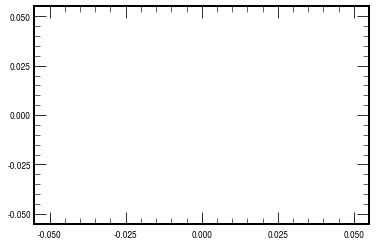

In [5]:
plt.plot()
hep.style.use(hep.style.CMS)
mpl.rcParams["figure.facecolor"] = "white"
plt.style.use(cms_styles.CMS_petroff_10)

In [6]:
def merge_runs(plots, run):
    names = [
        "Higgs",
        "TTV",
        "ST_NLO",
        "WJets",
        "VV+VVV",
        "TT_powheg",
        "DY",
        "QCD_Pt_MuEnrichedPt5",
        "total_bkg",
    ]
    # Add signal processes
    signal_processes = list(
        set(p[:-5] for p in plots.keys() if re.search("GluGluToSUEP.*13TeV", p))
    )
    # Remove 2016APV for now
    # years = ["2016APV", "2016", "2017", "2018"]
    years = ["2016", "2017", "2018"]
    if run == "Run3":
        names.remove("TTV")
        names.remove("ST_NLO")
        years = ["2022", "2022EE", "2023", "2023BPix"]
        # Add signal processes
        signal_processes = list(
            set(p[:-5] for p in plots.keys() if re.search("GluGluToSUEP.*13p6TeV", p))
        )
    names.append("Data")
    names.extend(signal_processes)
    run_plots = {}
    for name in names:
        run_plots[f"{name}_{run}"] = {}
        for year in years:
            if f"{name}_{year}" not in plots.keys():
                continue
            for plot in plots[f"{name}_{year}"]:
                if plot not in run_plots[f"{name}_{run}"].keys():
                    run_plots[f"{name}_{run}"][plot] = plots[f"{name}_{year}"][
                        plot
                    ].copy()
                else:
                    run_plots[f"{name}_{run}"][plot] += plots[f"{name}_{year}"][plot]
    return run_plots

In [7]:
plots = {}
years_to_load = [
    # "2016APV",
    # "2016",
    # "2017",
    "2018",
    # "2022",
    # "2022EE",
    # "2023",
    # "2023BPix",
]
for year in track(years_to_load, description="Loading plots"):
    plots = plots | plot_utils.loader(
        tag=f"discrepancies_Jun2025_{year}",
        era=year,
        load_data=True,
    )
# run2_plots = merge_runs(plots, "Run2")
# plots = plots | run2_plots
# run3_plots = merge_runs(plots, "Run3")
# plots = plots | run3_plots

Loading plots ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00
Loading plots ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00

nMuon =  2.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


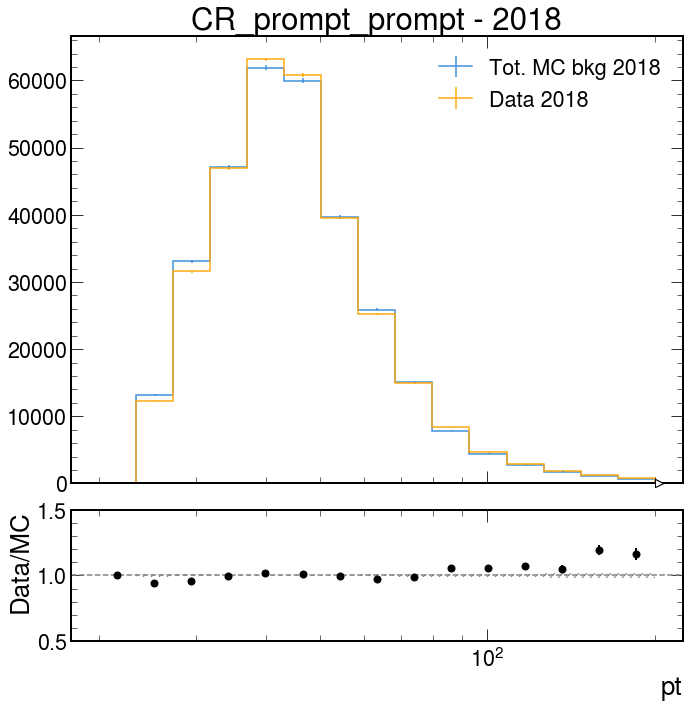

nMuon =  3.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


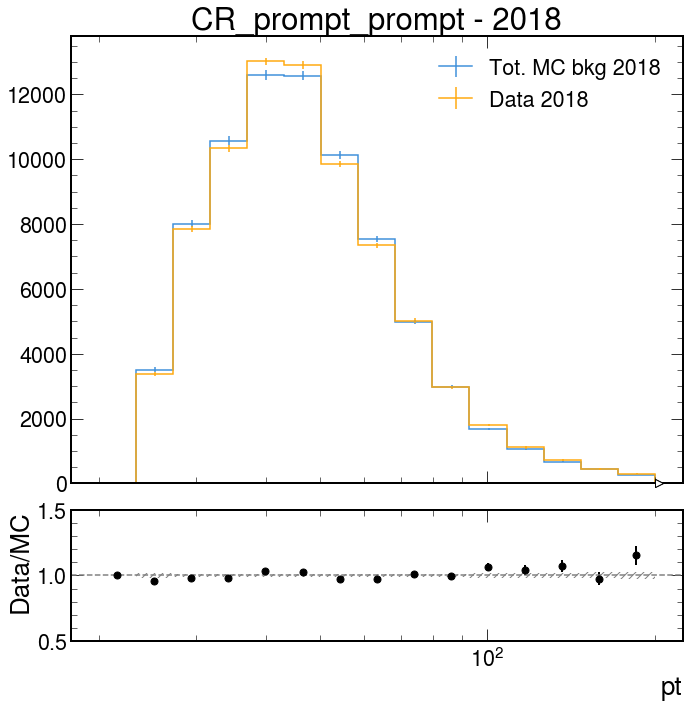

nMuon =  4.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


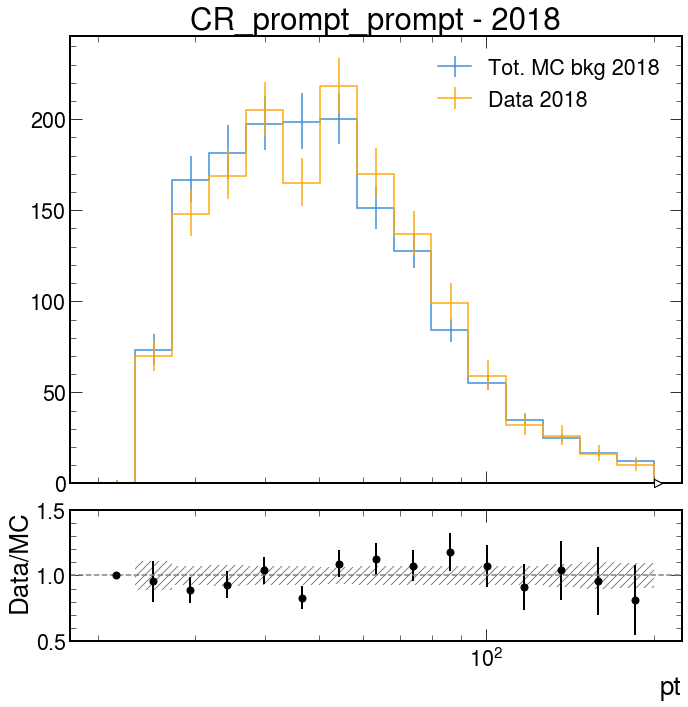

nMuon =  5.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


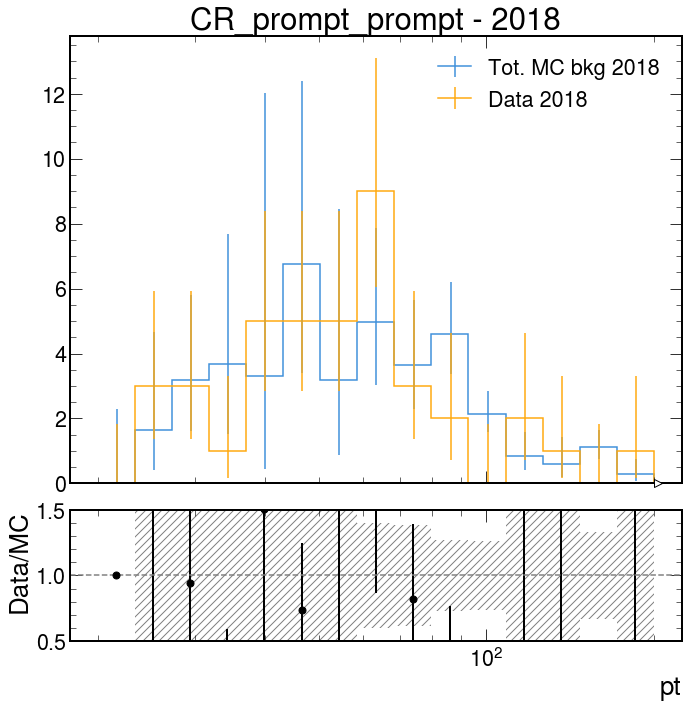

nMuon =  2.0

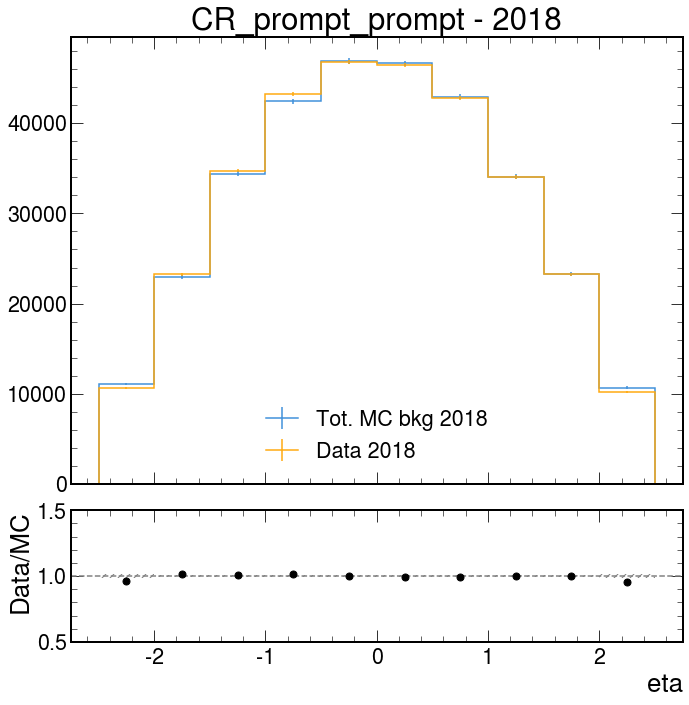

nMuon =  3.0

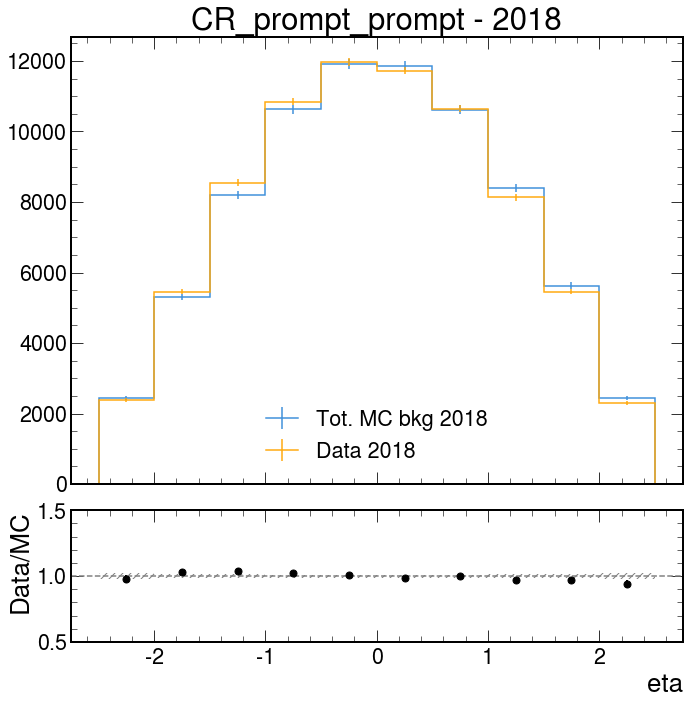

nMuon =  4.0

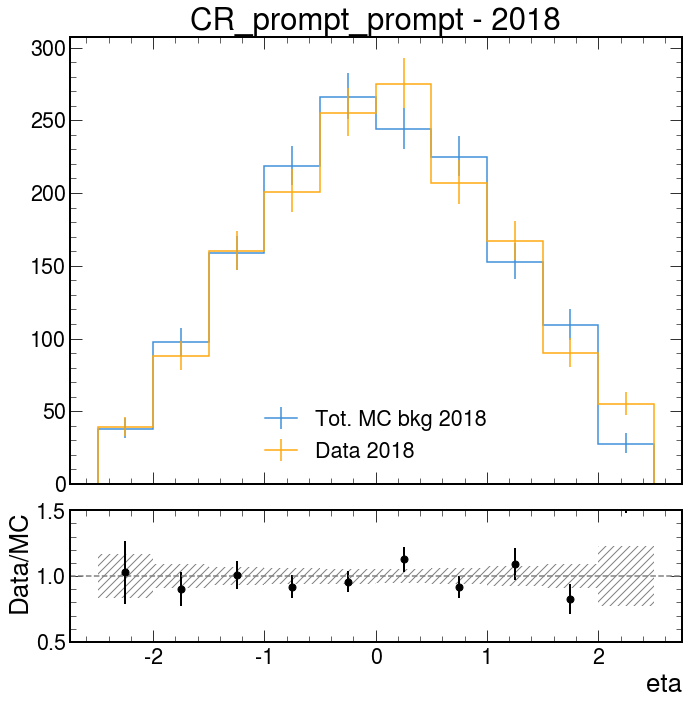

nMuon =  5.0

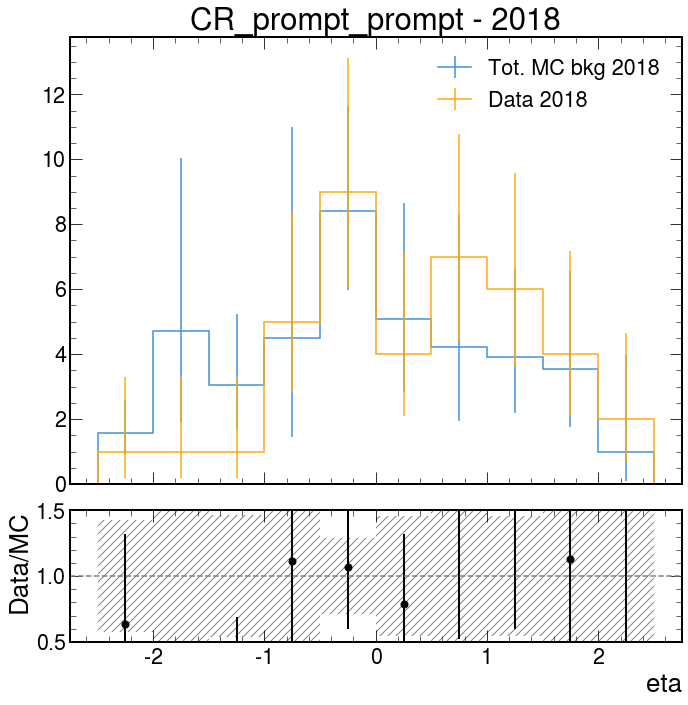

nMuon =  2.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


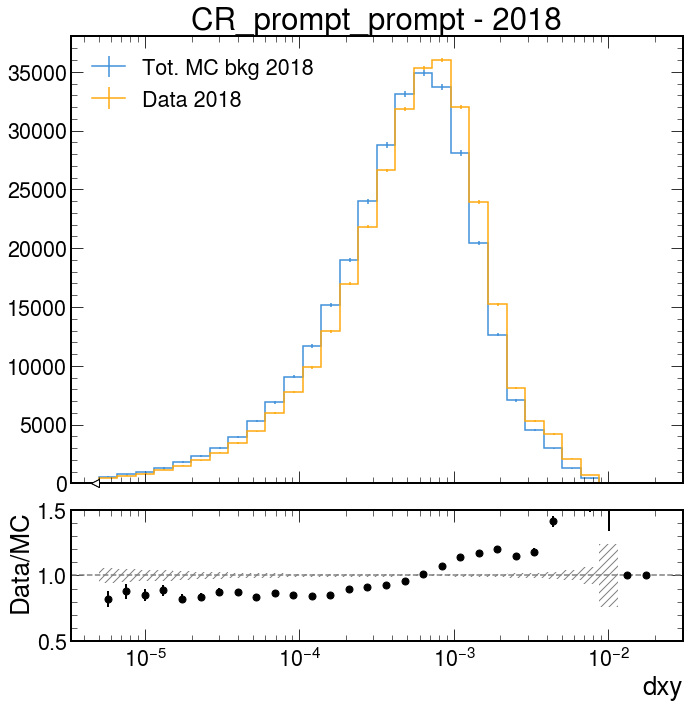

nMuon =  3.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


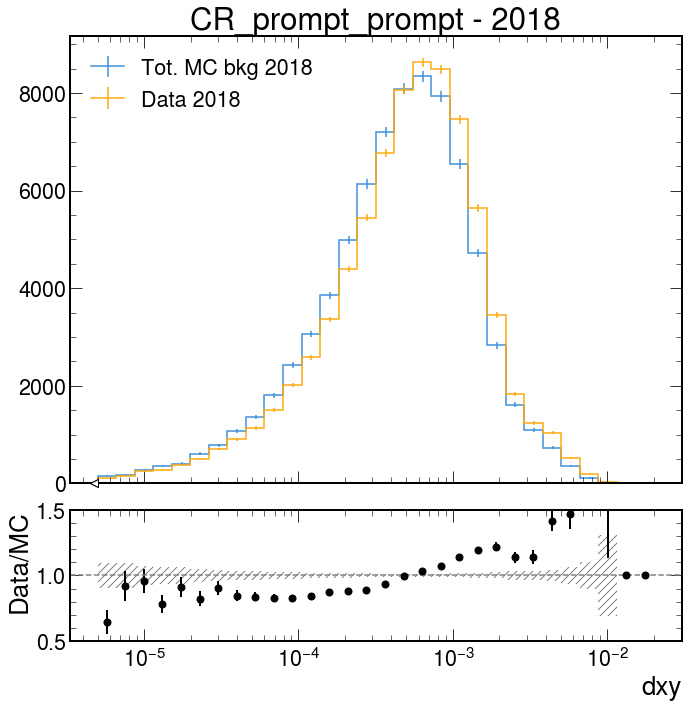

nMuon =  4.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


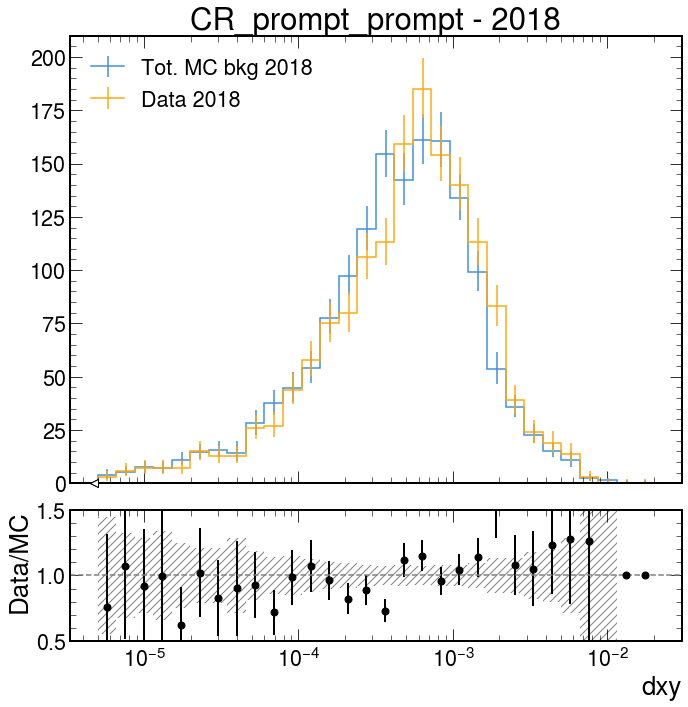

nMuon =  5.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


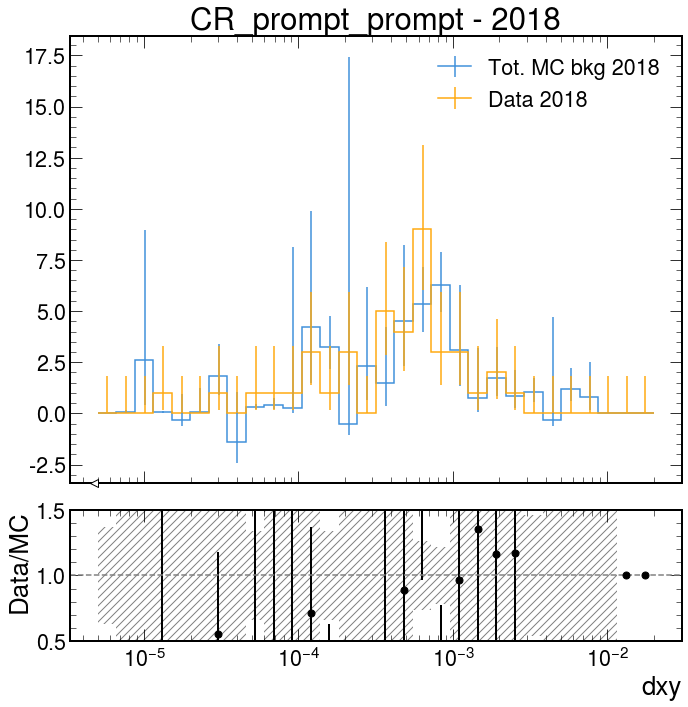

nMuon =  2.0

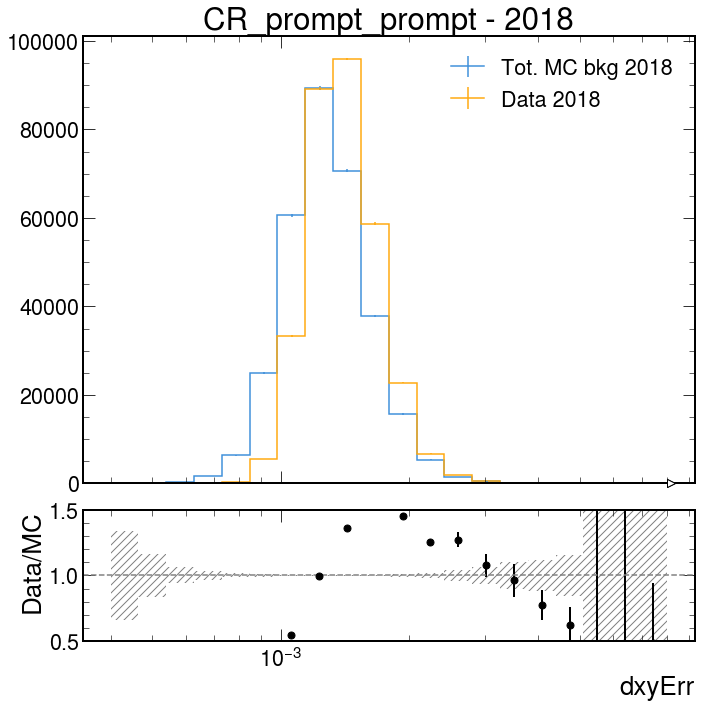

nMuon =  3.0

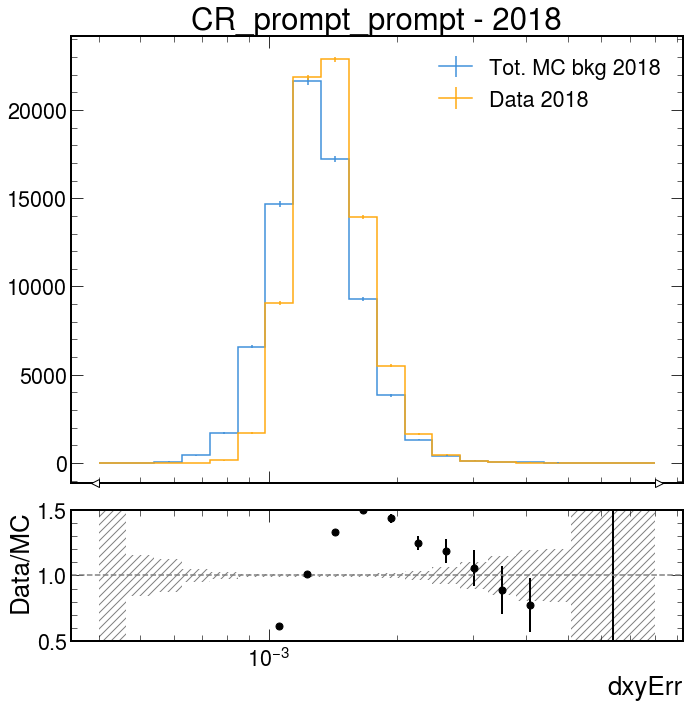

nMuon =  4.0

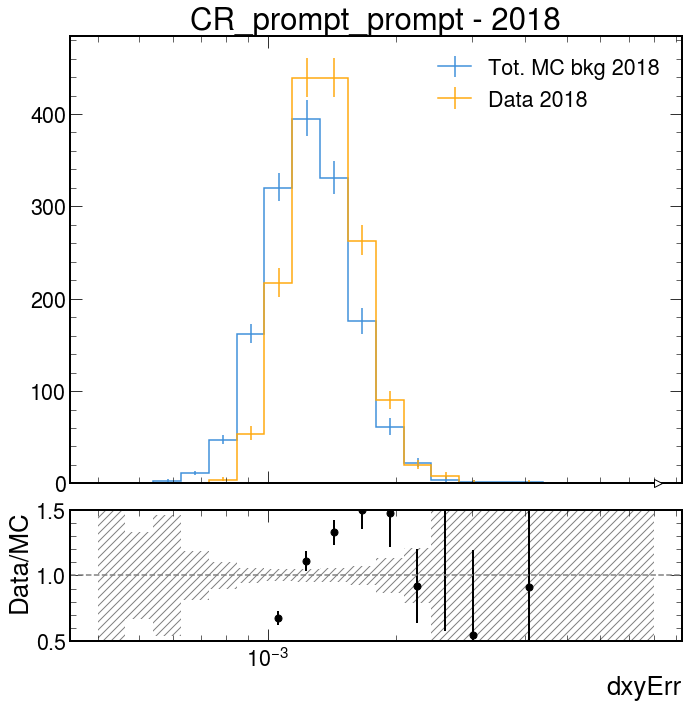

nMuon =  5.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


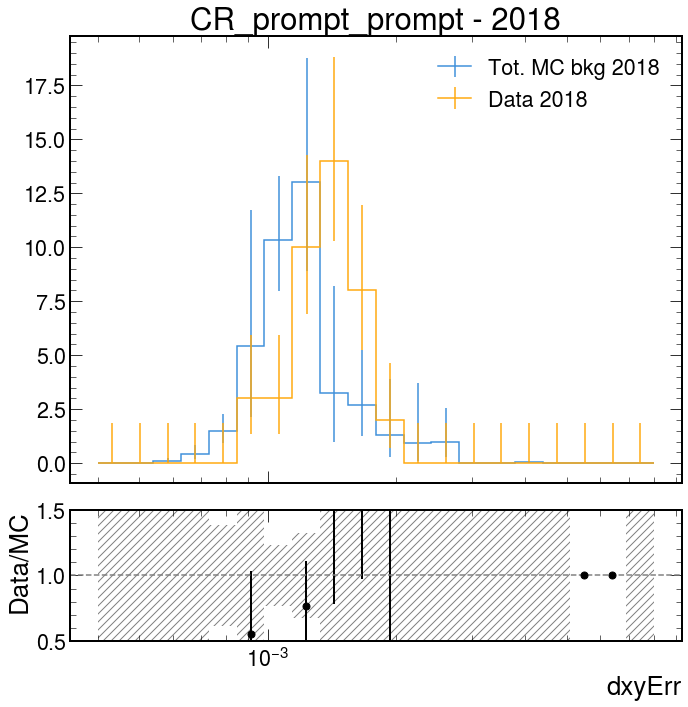

nMuon =  2.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


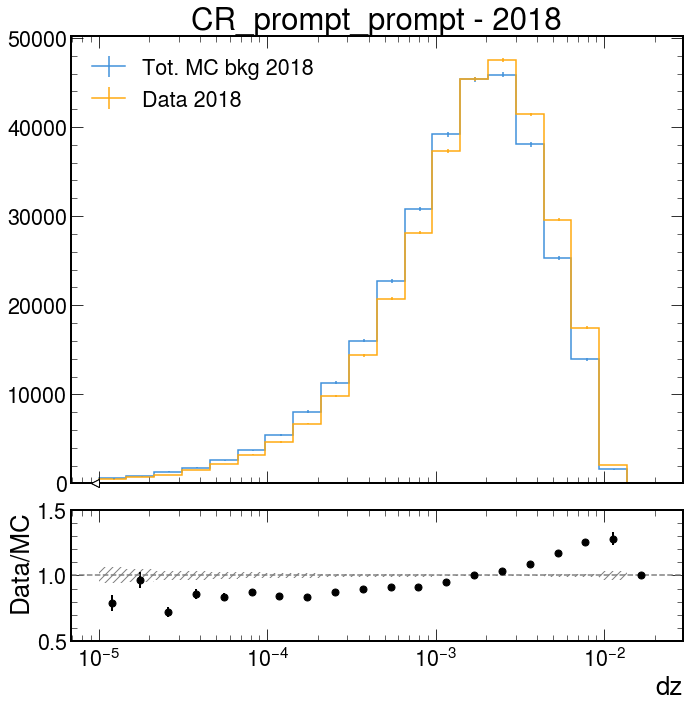

nMuon =  3.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


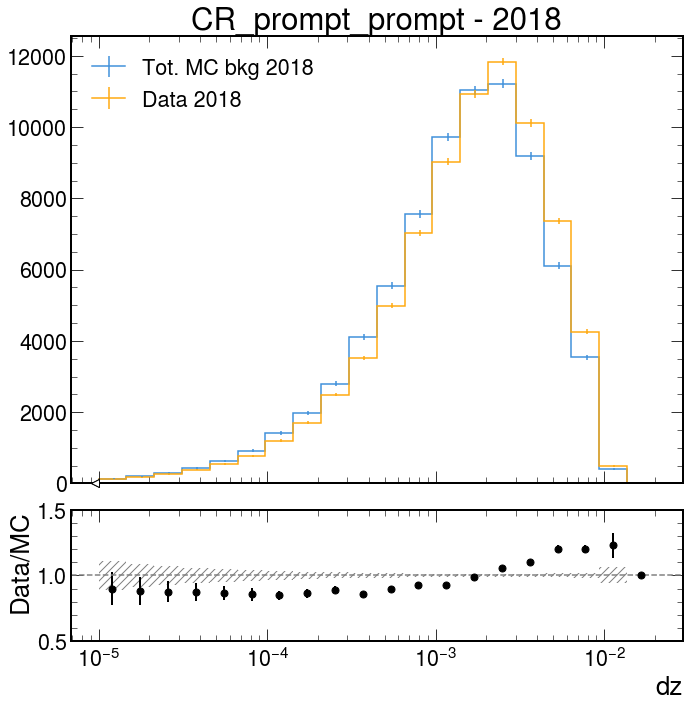

nMuon =  4.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


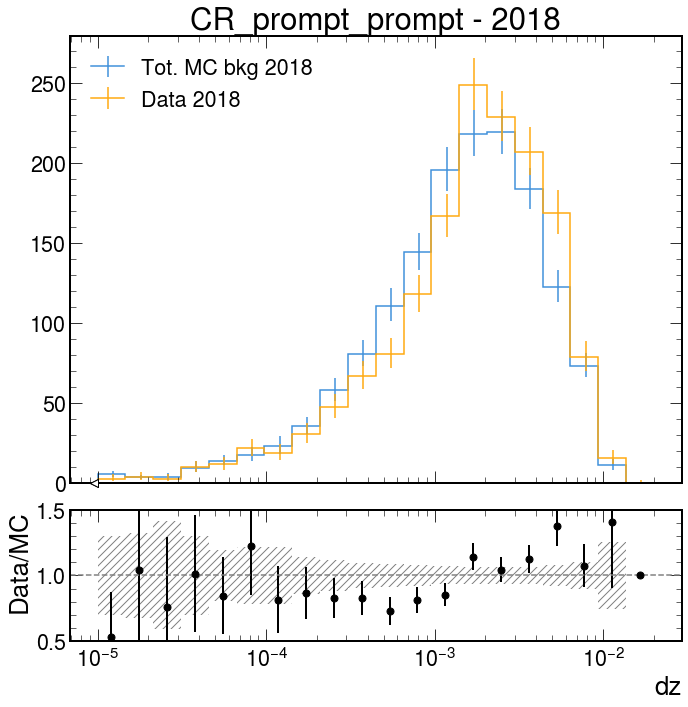

nMuon =  5.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


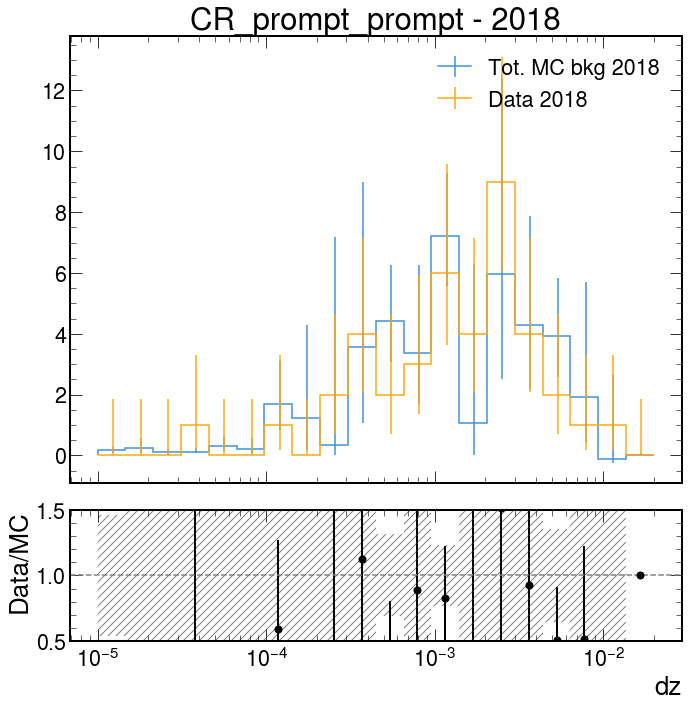

nMuon =  2.0

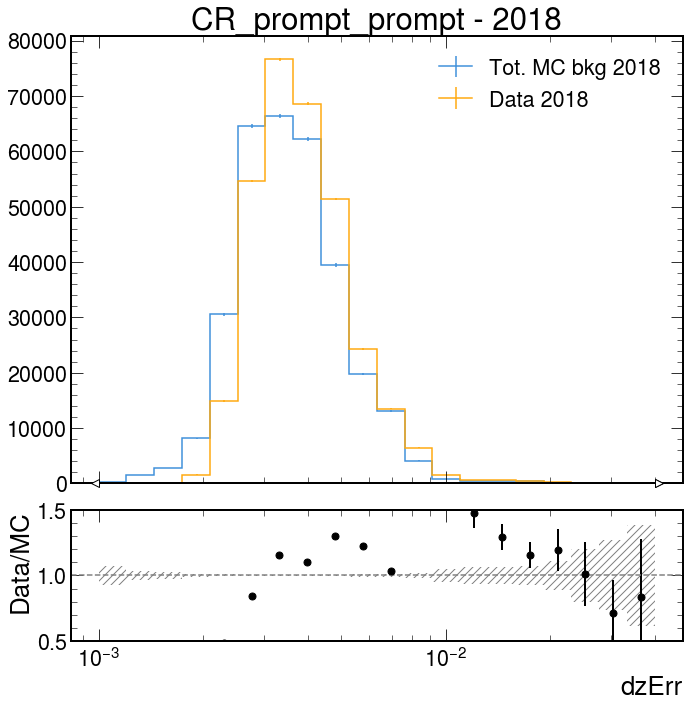

nMuon =  3.0

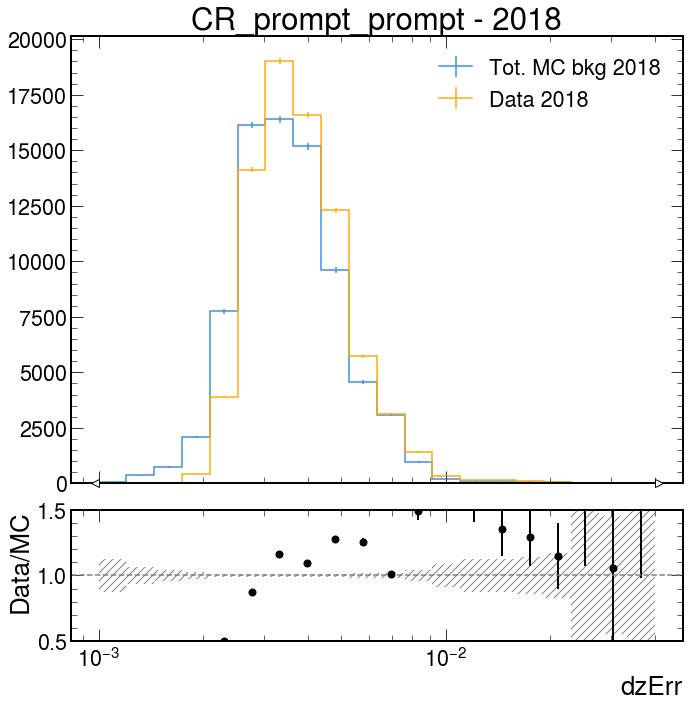

nMuon =  4.0

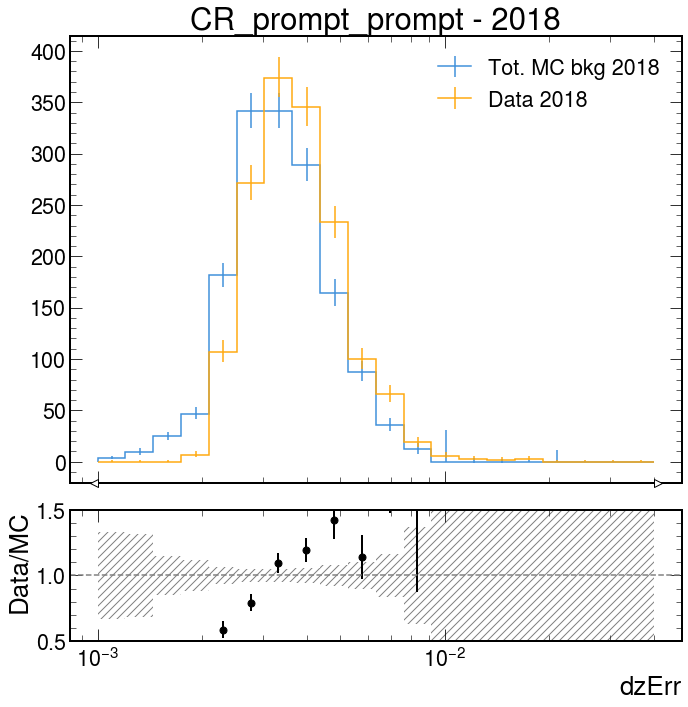

nMuon =  5.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


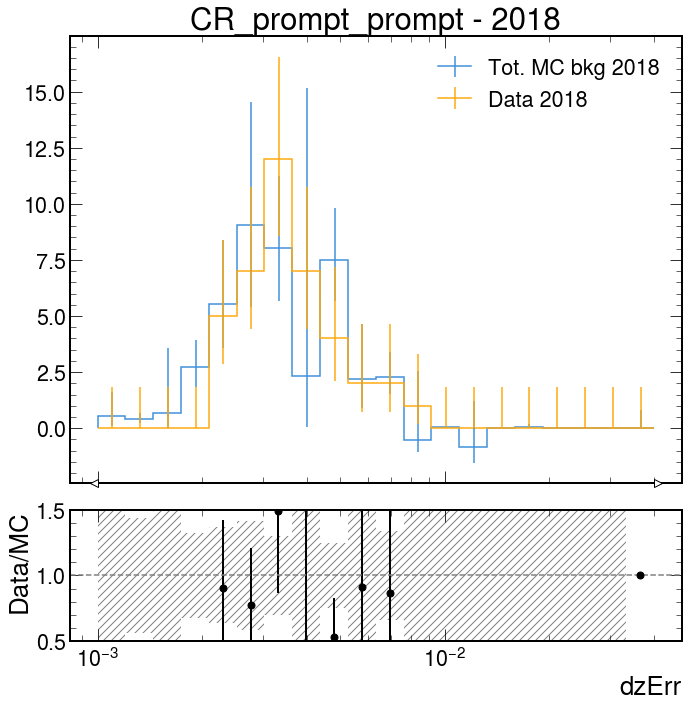

nMuon =  2.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


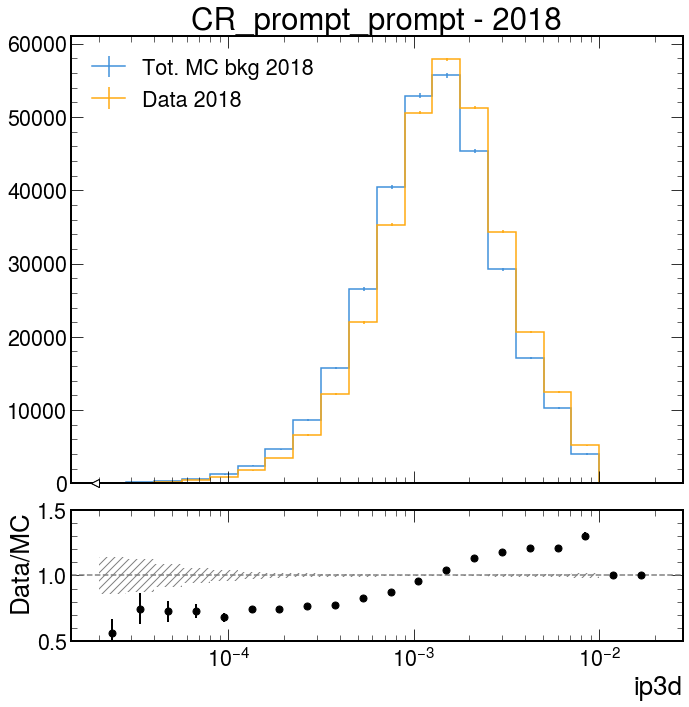

nMuon =  3.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


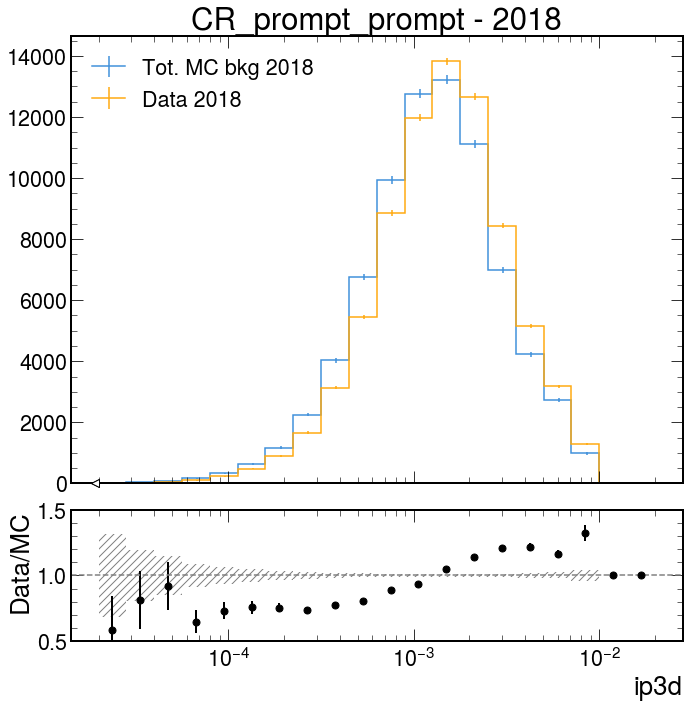

nMuon =  4.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


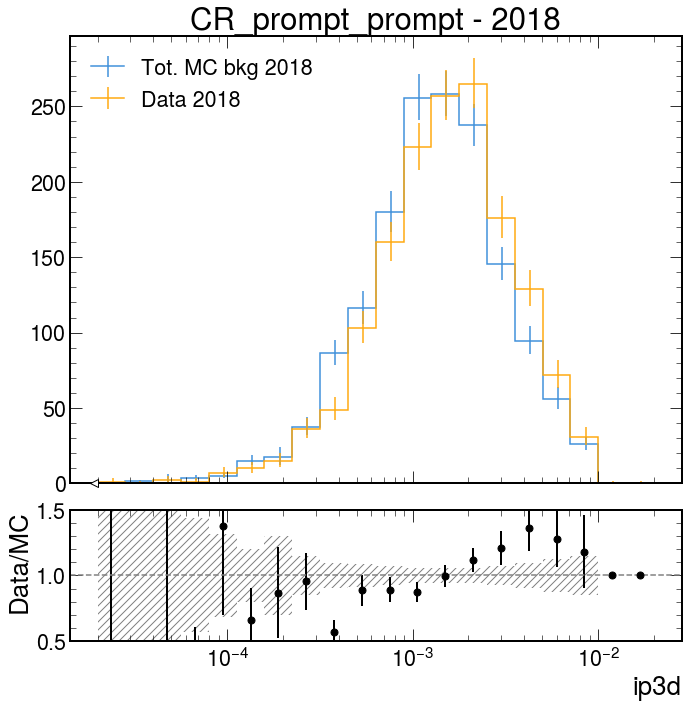

nMuon =  5.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


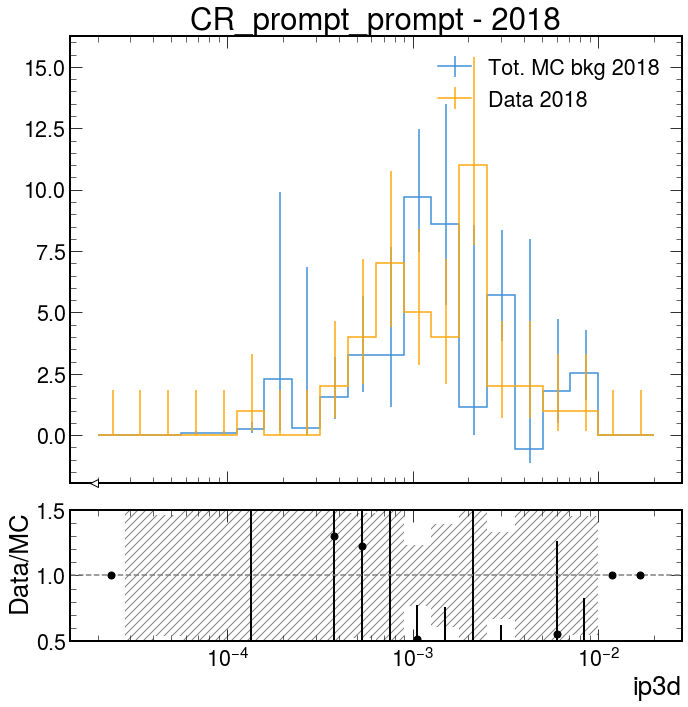

nMuon =  2.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


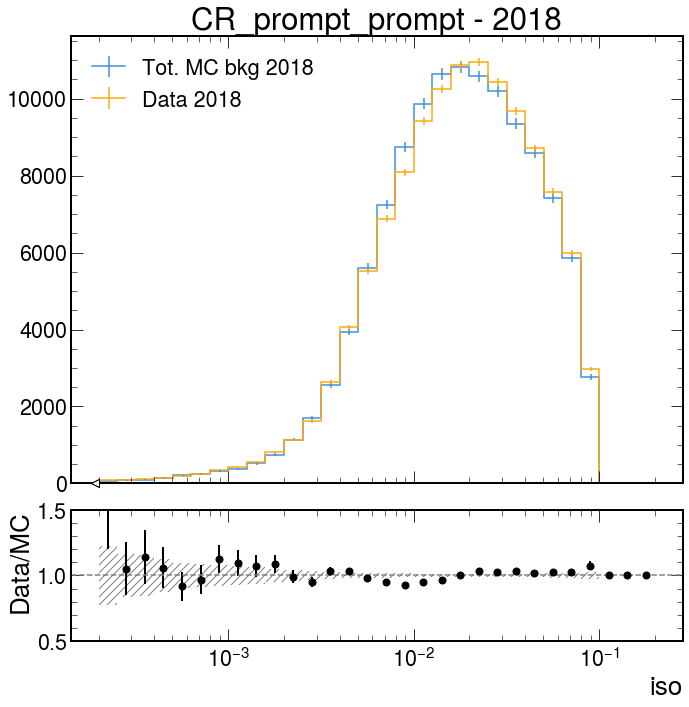

nMuon =  3.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


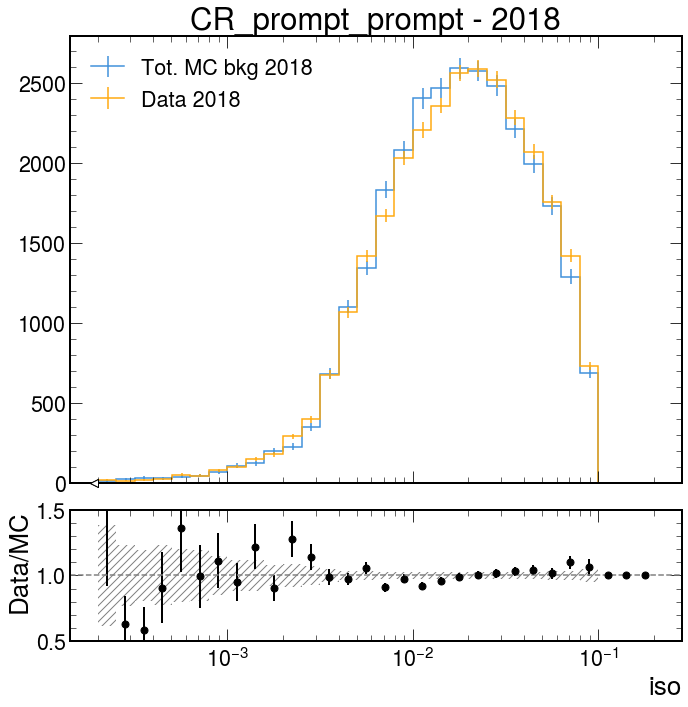

nMuon =  4.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


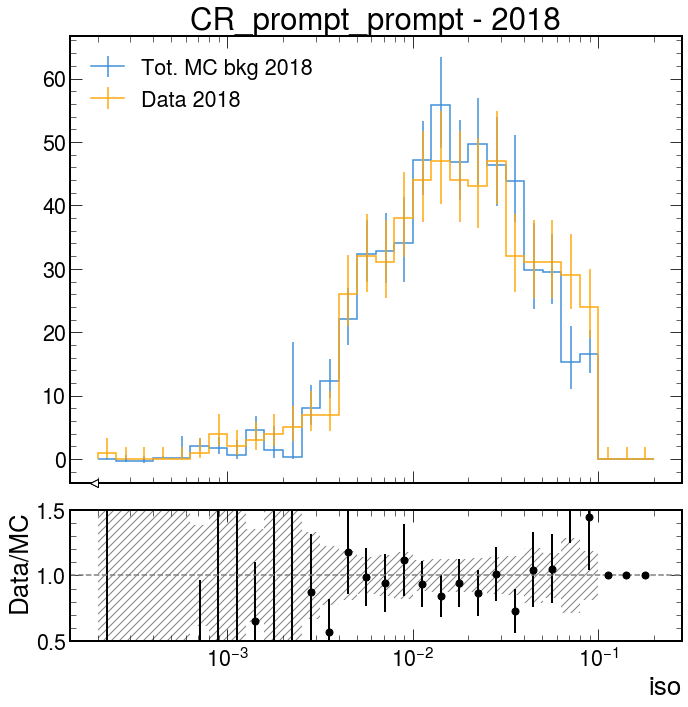

nMuon =  5.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


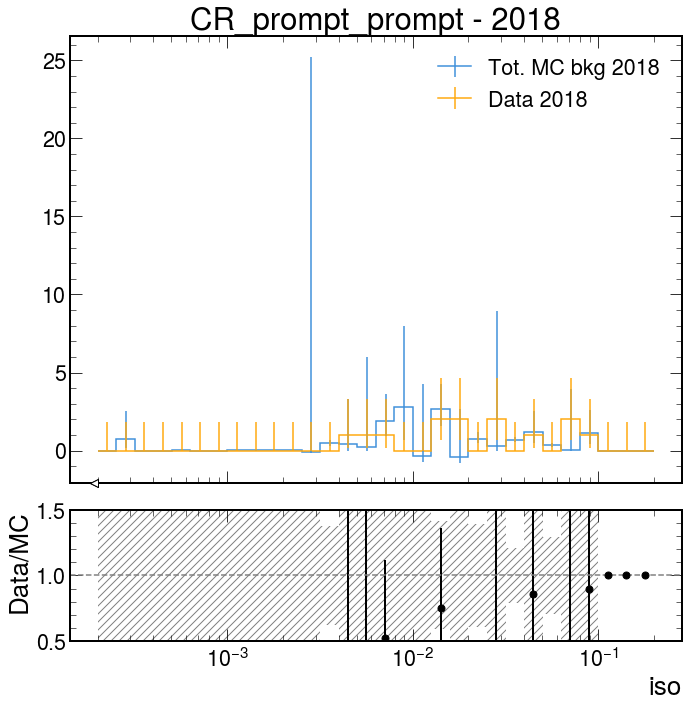

nMuon =  2.0

nMuon =  3.0

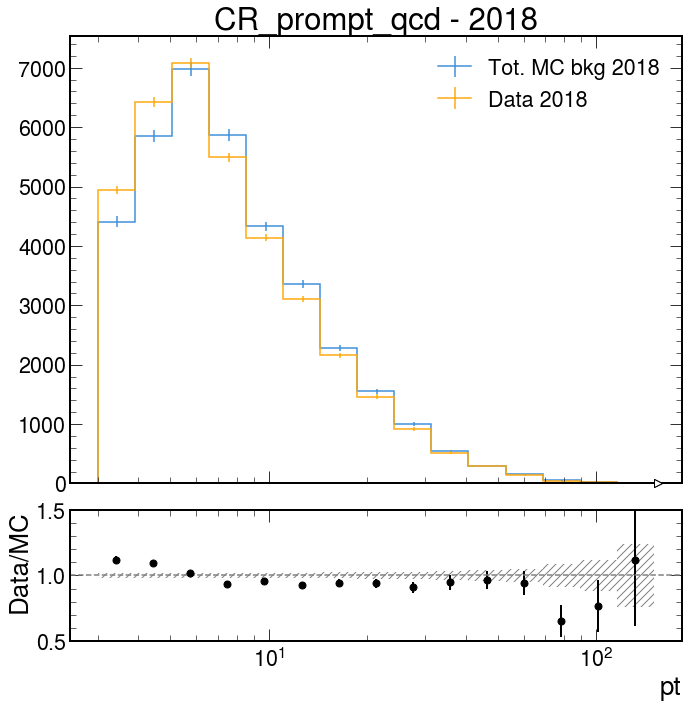

nMuon =  4.0

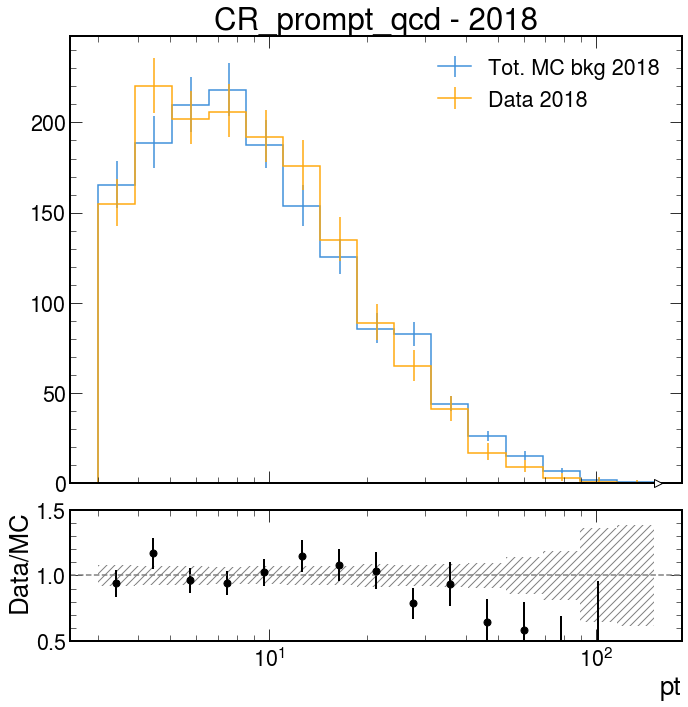

nMuon =  5.0

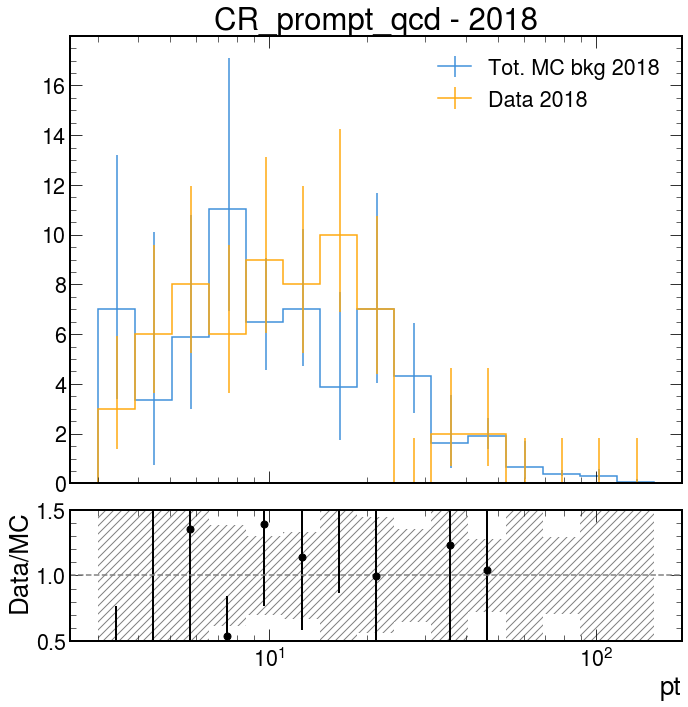

nMuon =  2.0

nMuon =  3.0

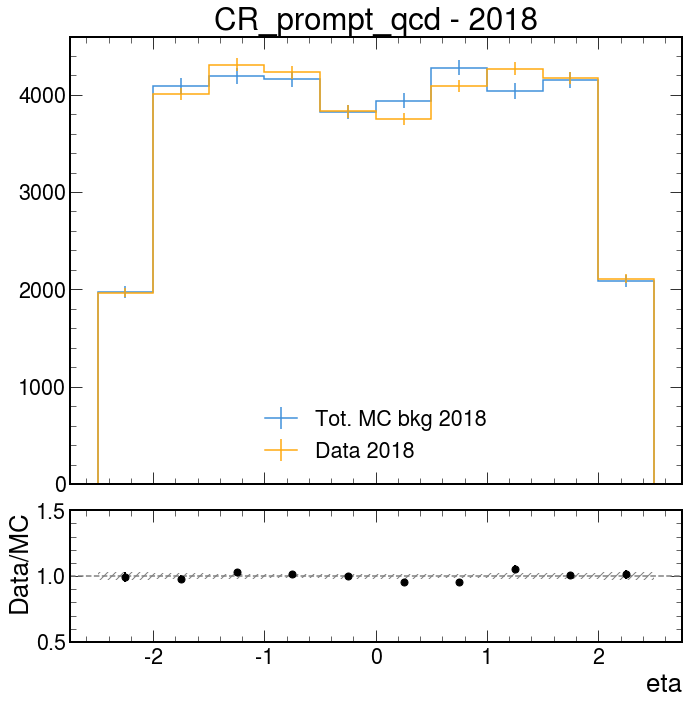

nMuon =  4.0

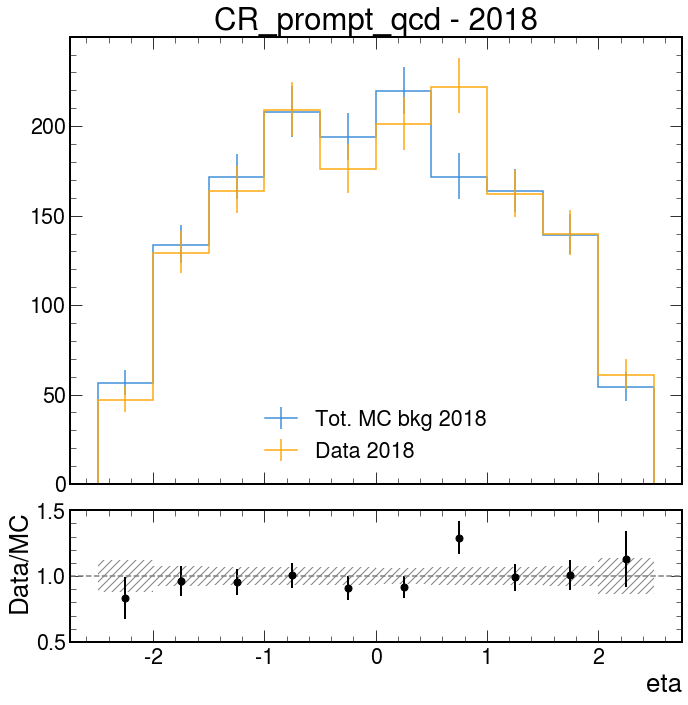

nMuon =  5.0

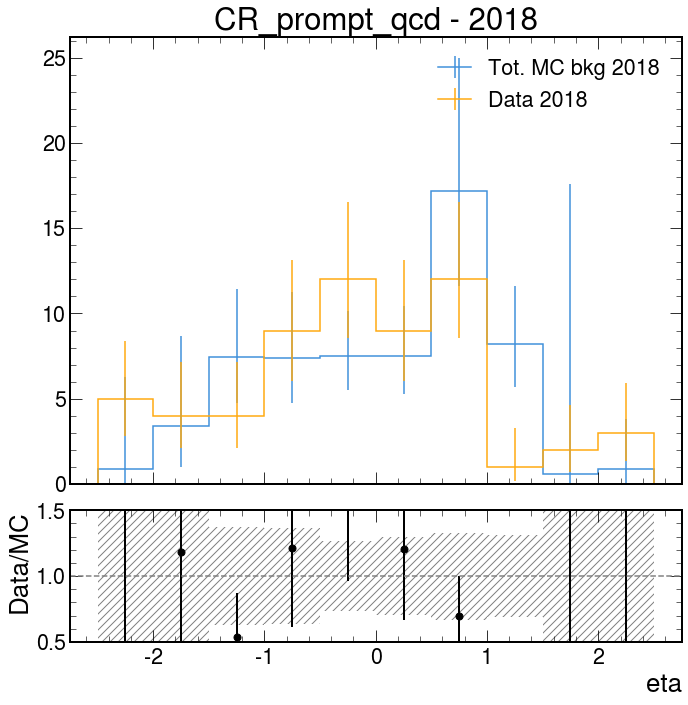

nMuon =  2.0

nMuon =  3.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


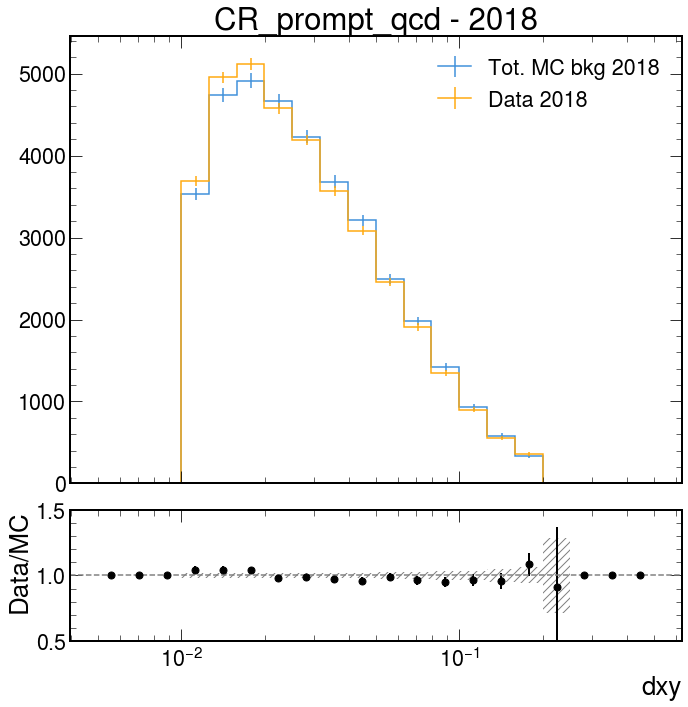

nMuon =  4.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


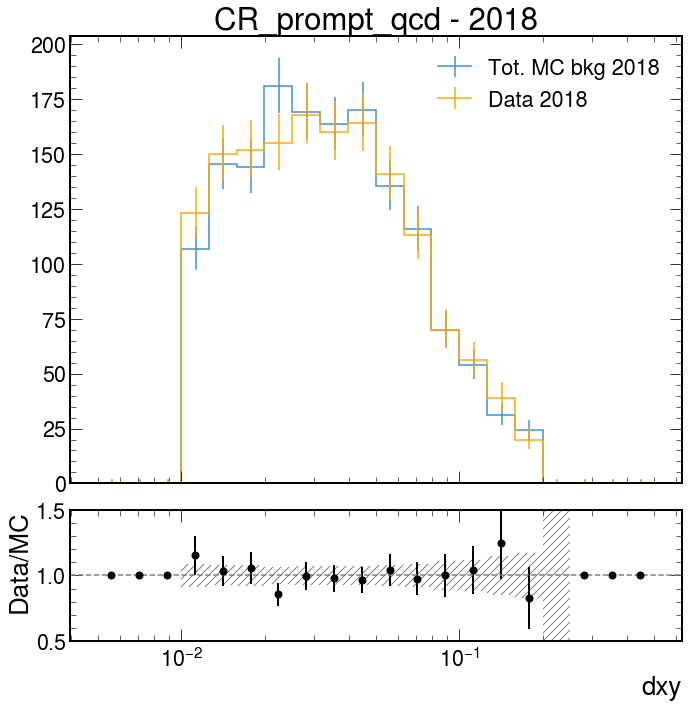

nMuon =  5.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


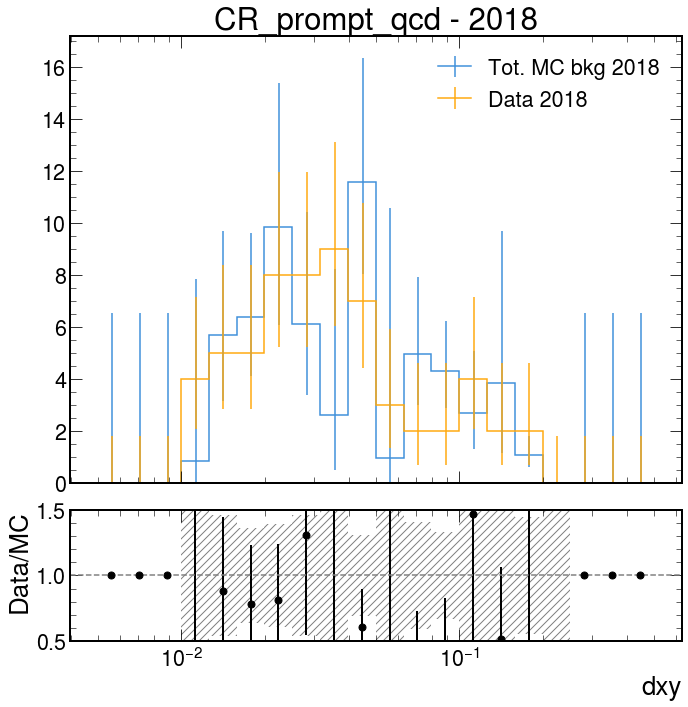

nMuon =  2.0

nMuon =  3.0

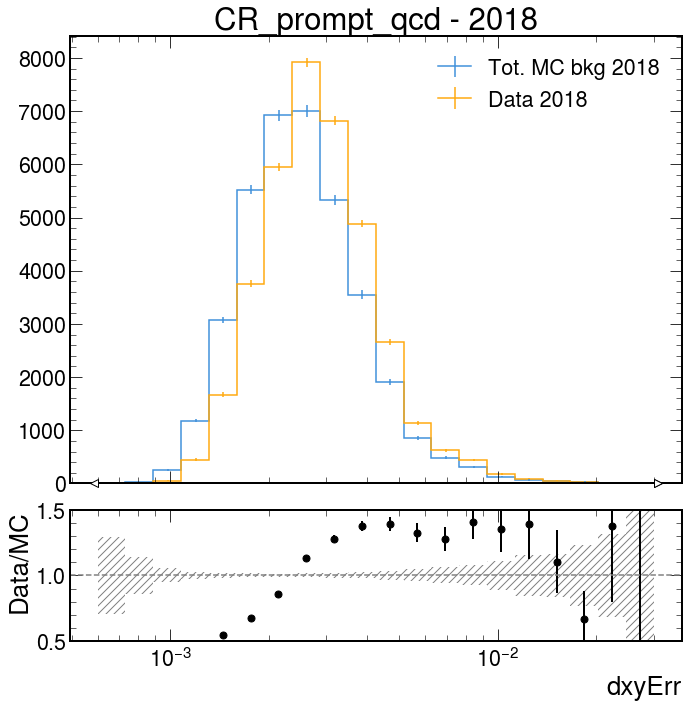

nMuon =  4.0

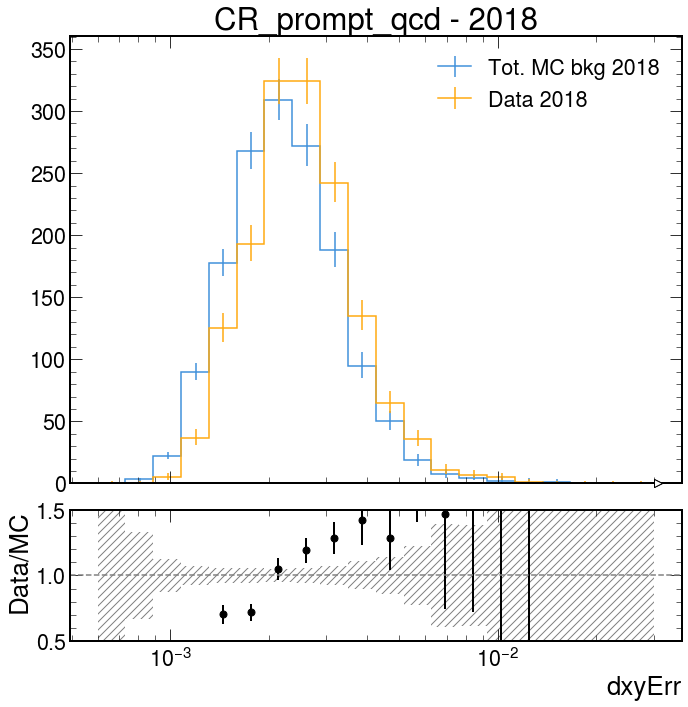

nMuon =  5.0

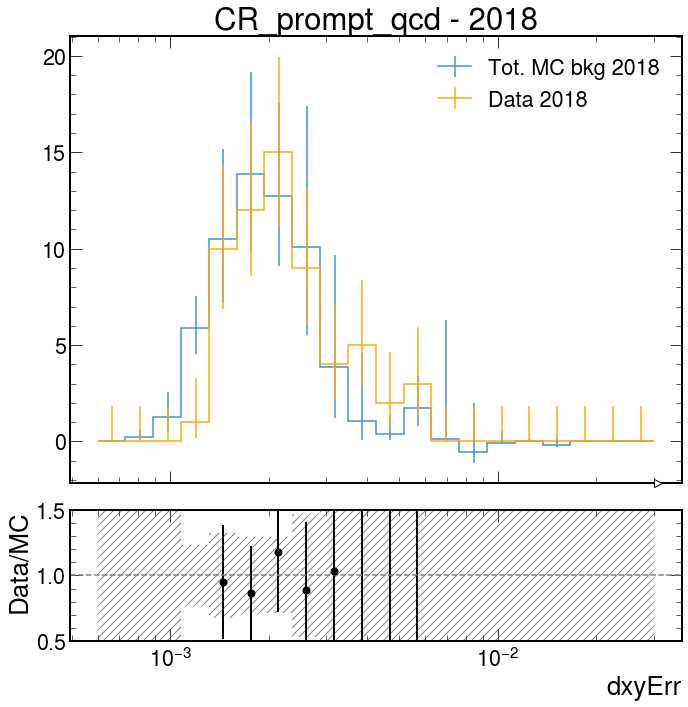

nMuon =  2.0

nMuon =  3.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


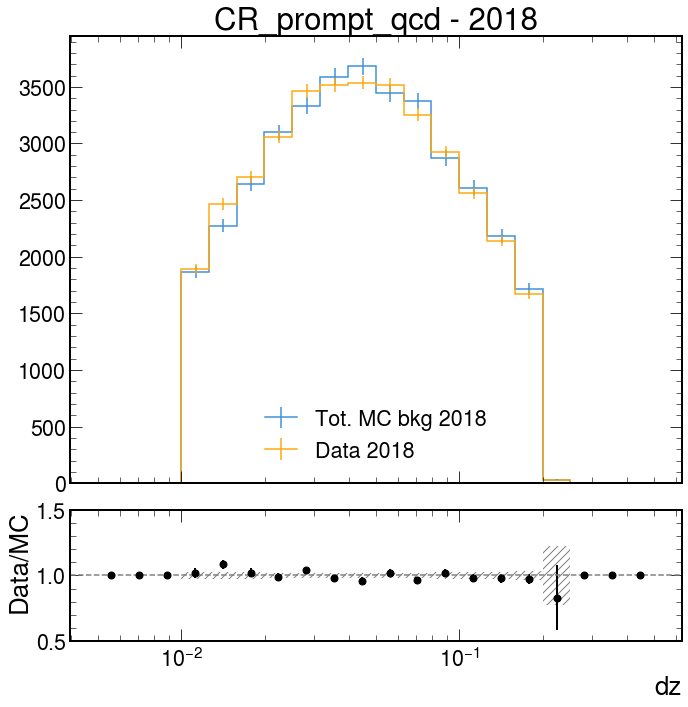

nMuon =  4.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


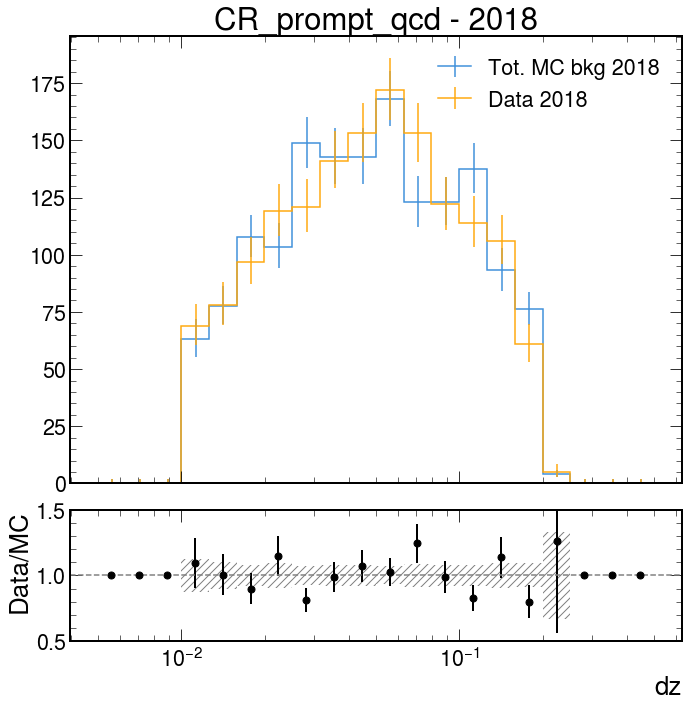

nMuon =  5.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


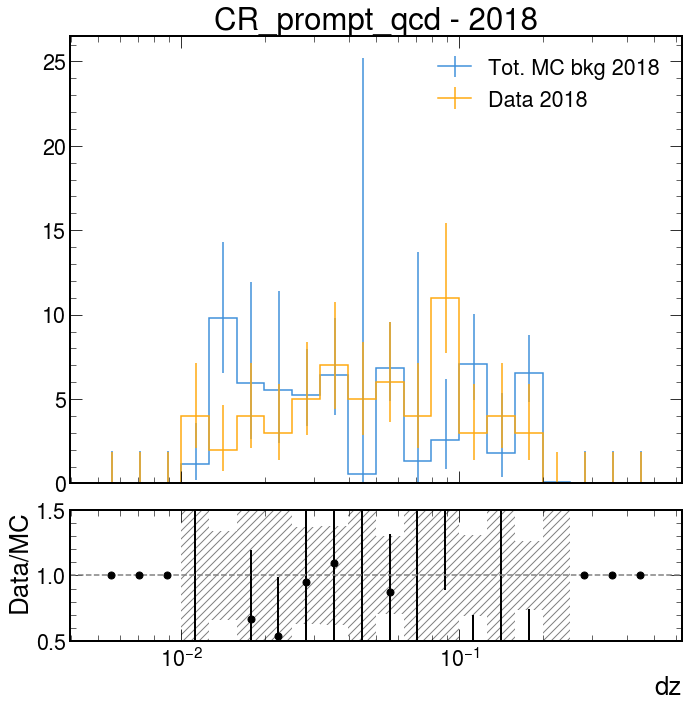

nMuon =  2.0

nMuon =  3.0

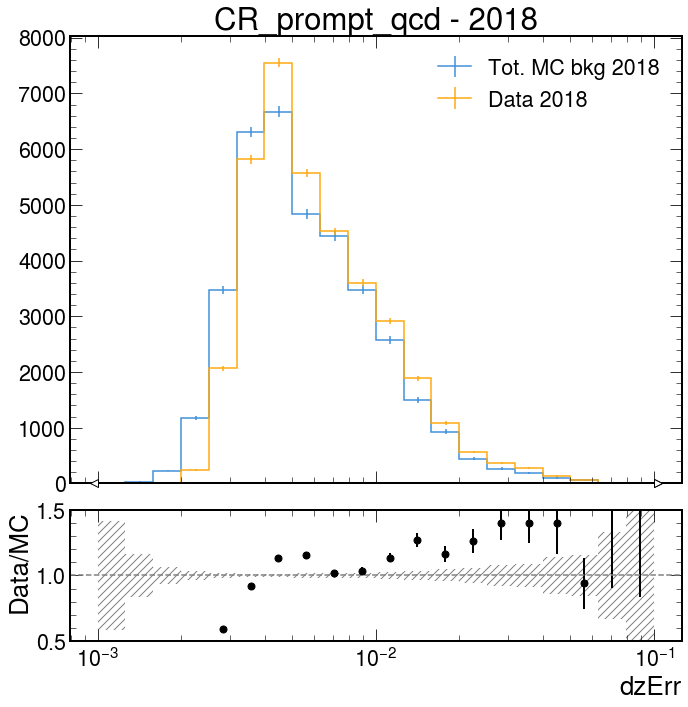

nMuon =  4.0

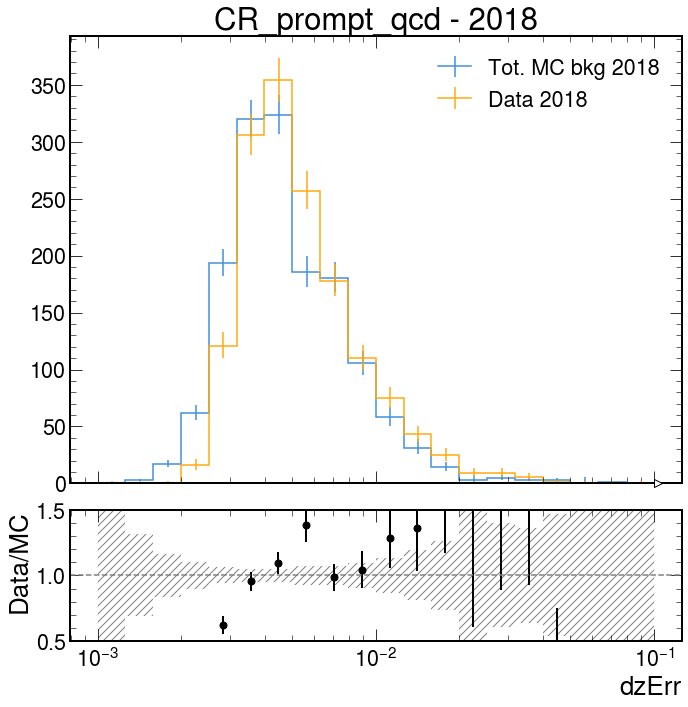

nMuon =  5.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


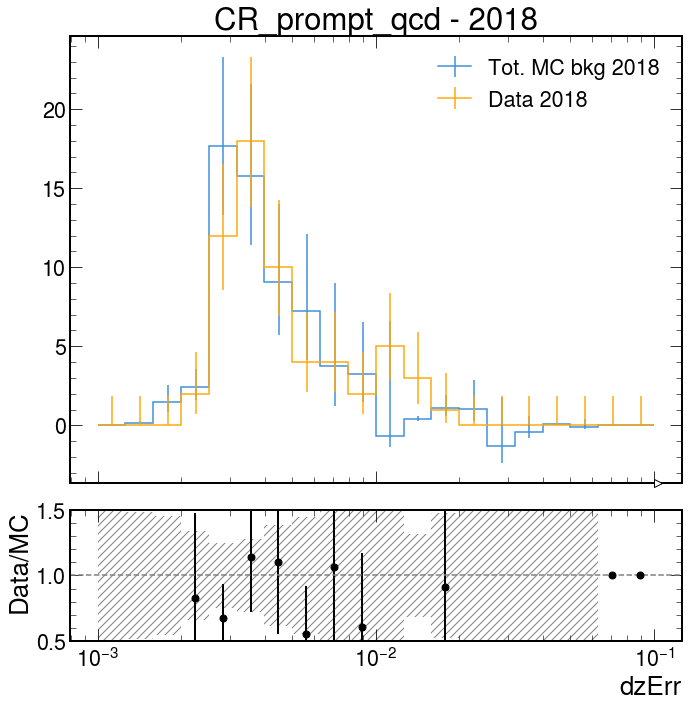

nMuon =  2.0

nMuon =  3.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


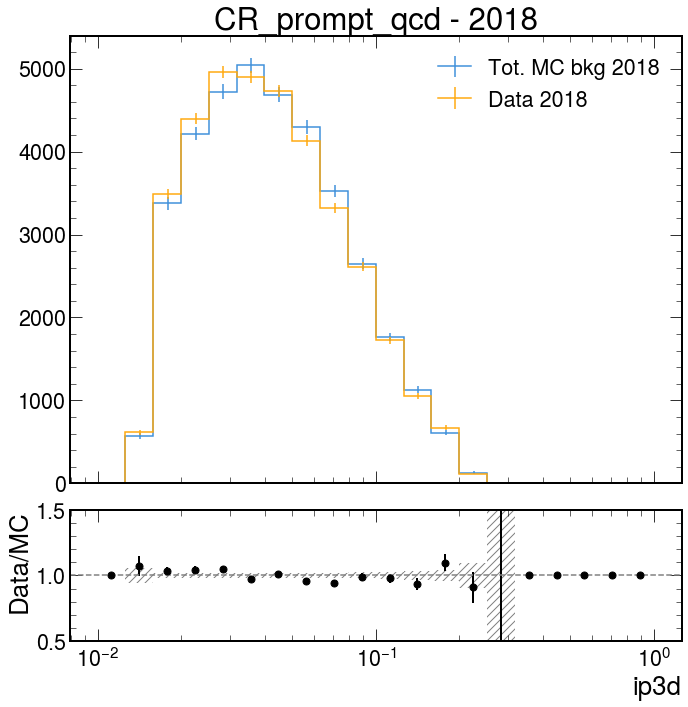

nMuon =  4.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


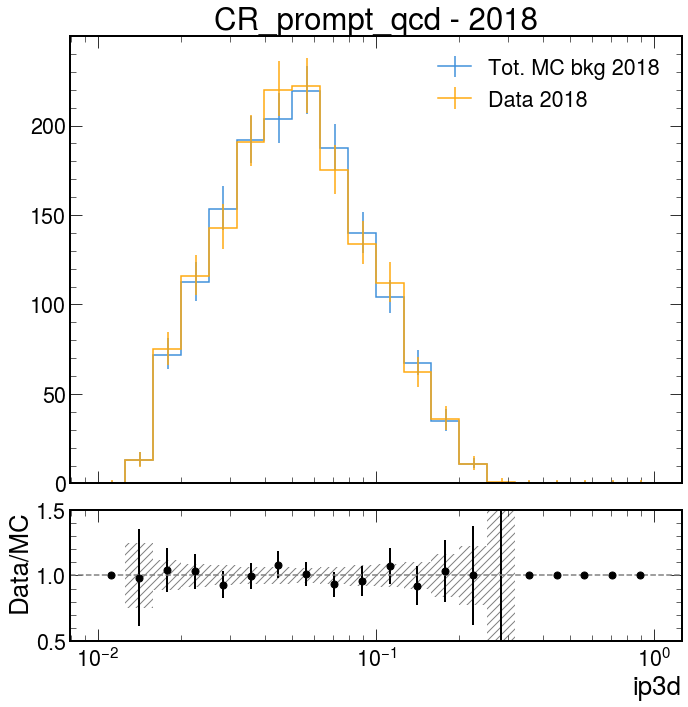

nMuon =  5.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


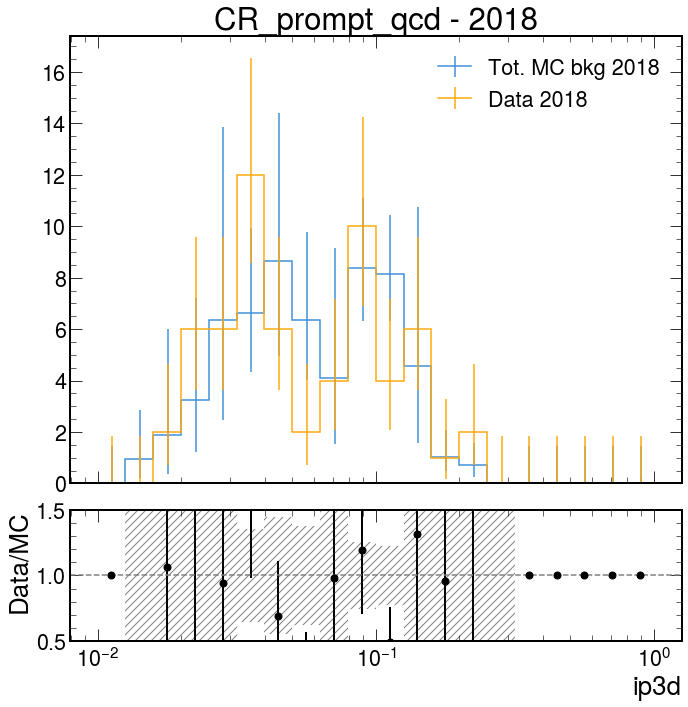

nMuon =  2.0

nMuon =  3.0

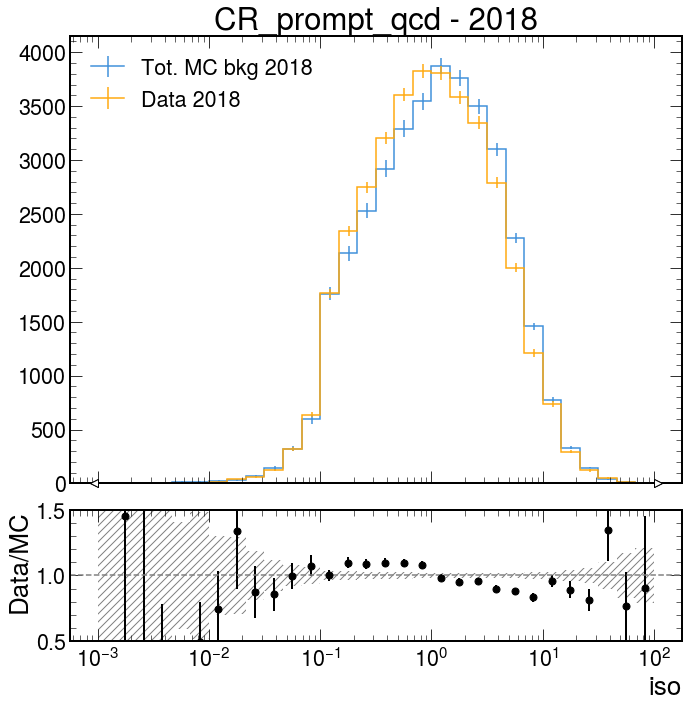

nMuon =  4.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


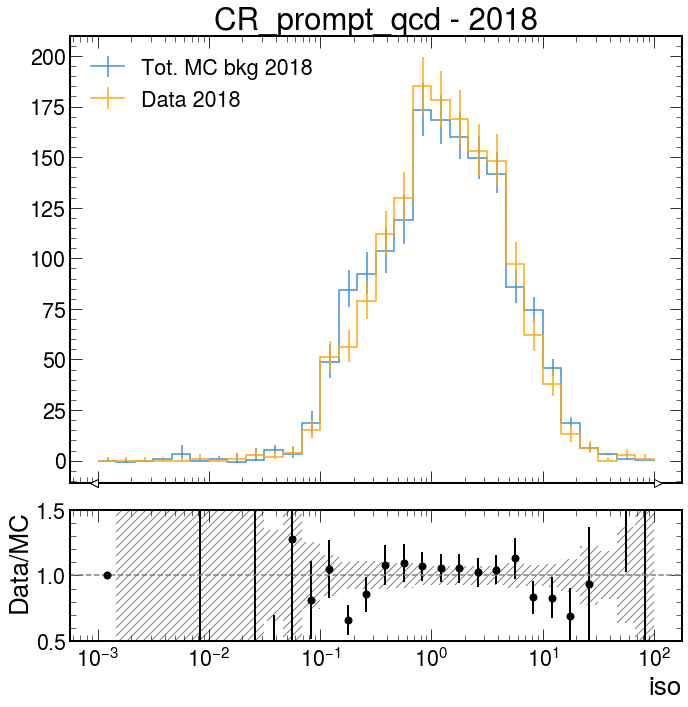

nMuon =  5.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


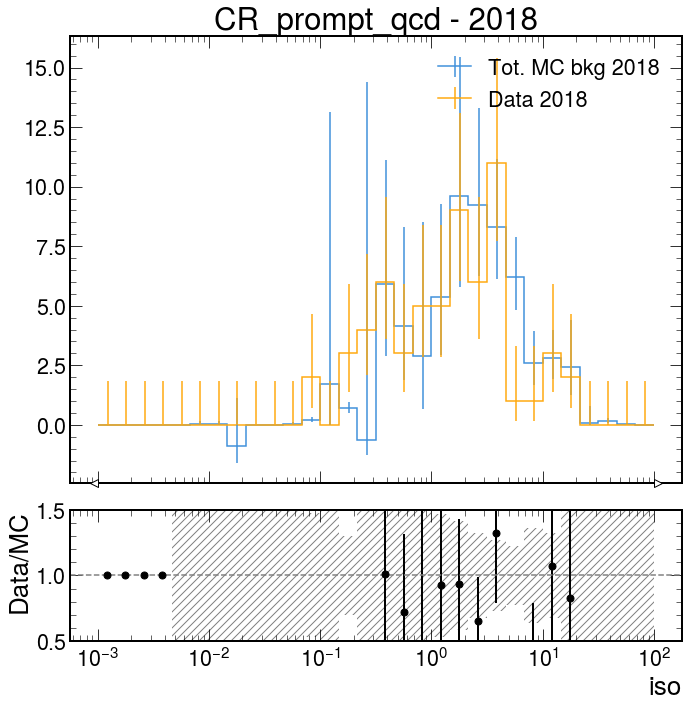

nMuon =  1.0

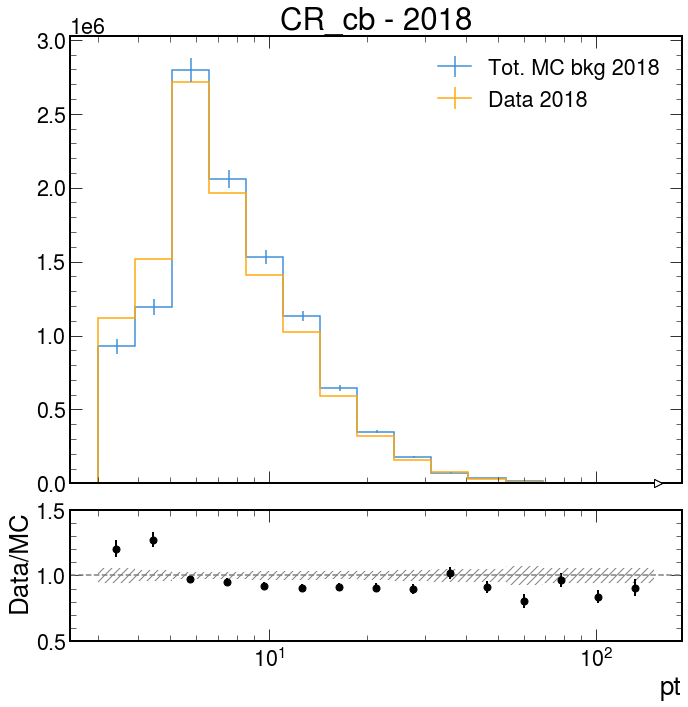

nMuon =  2.0

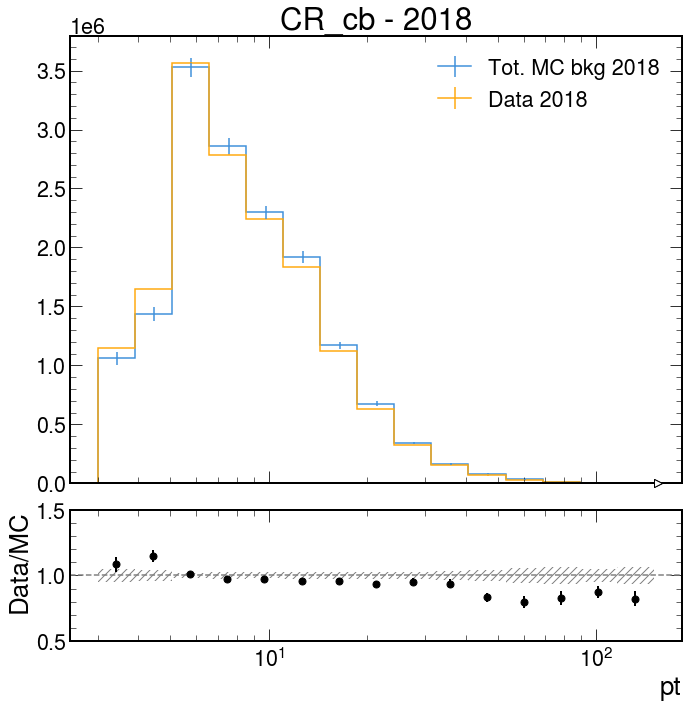

nMuon =  3.0

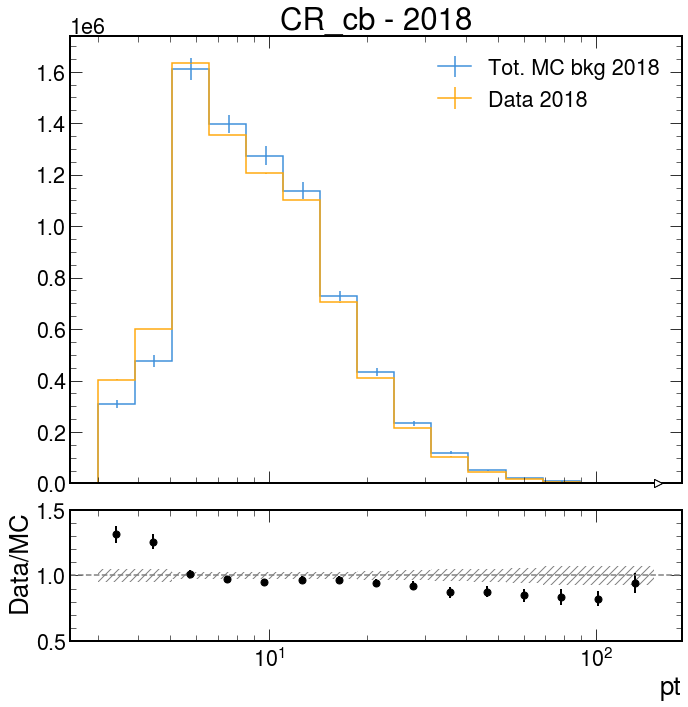

nMuon =  4.0

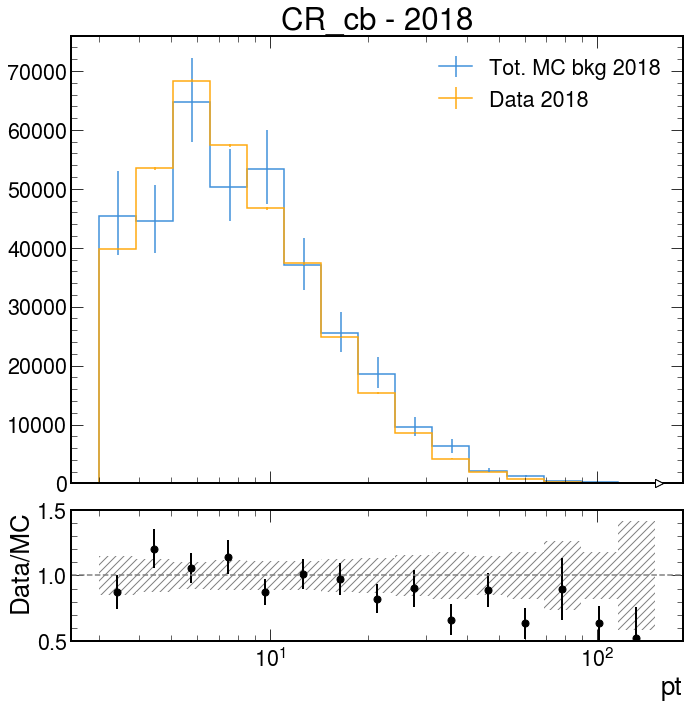

nMuon =  1.0

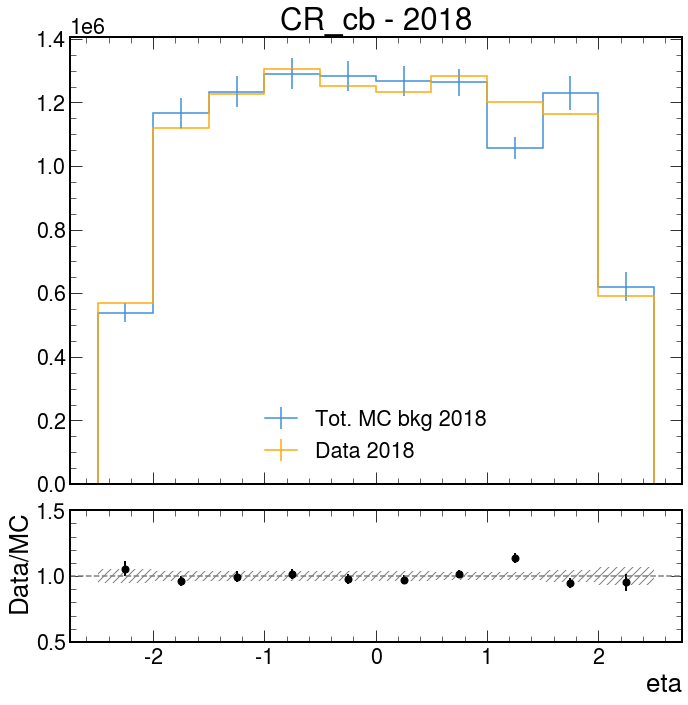

nMuon =  2.0

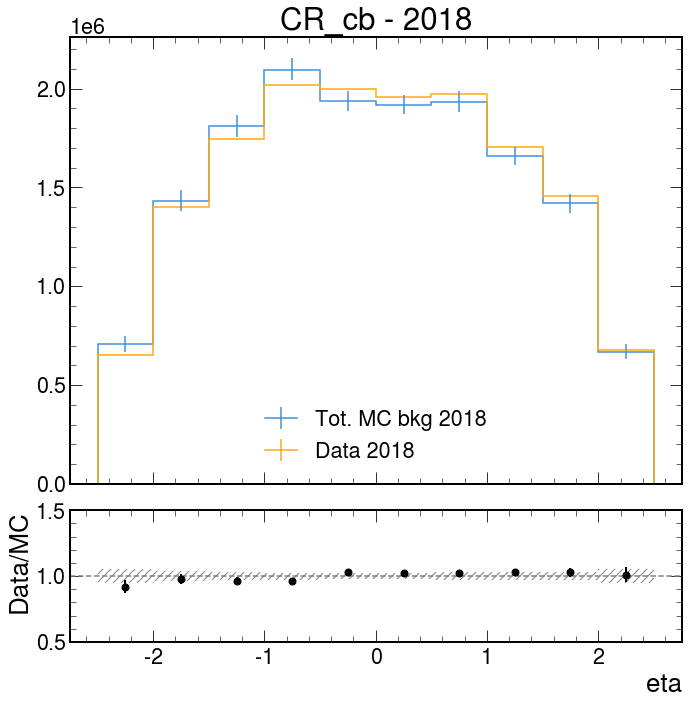

nMuon =  3.0

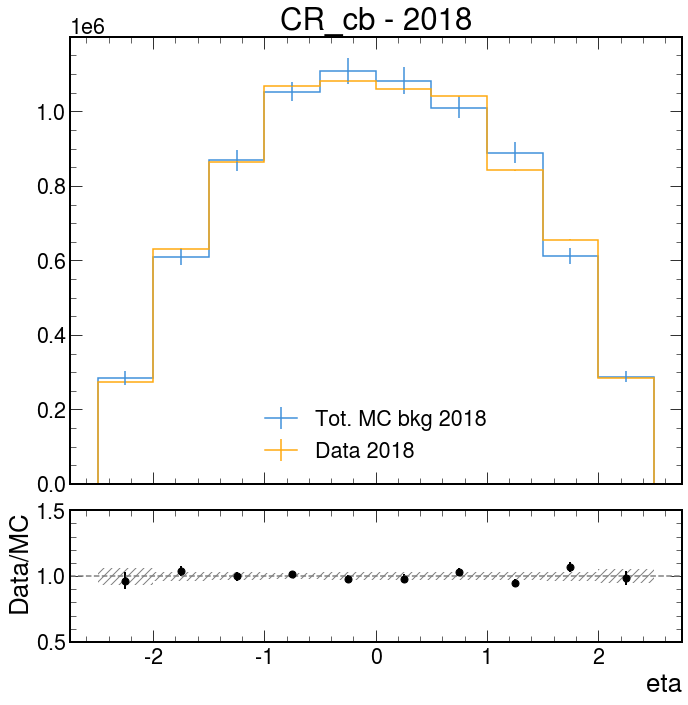

nMuon =  4.0

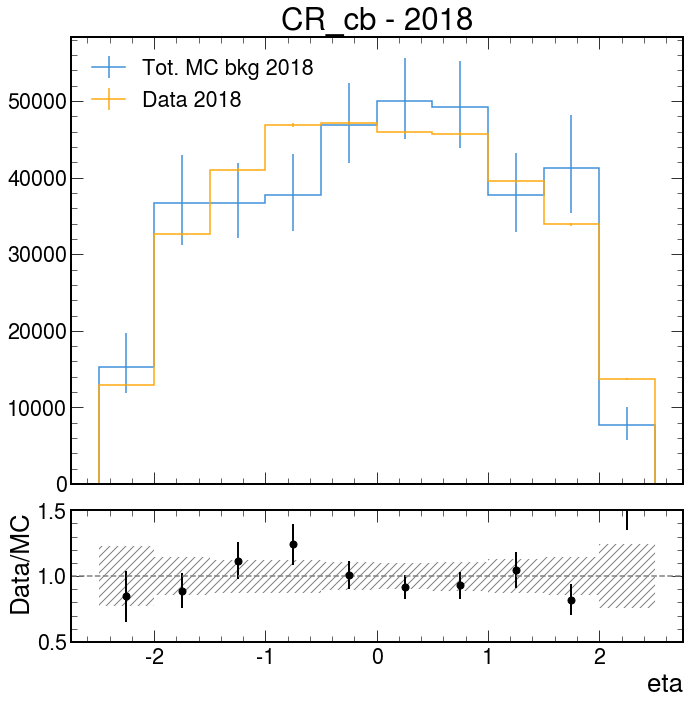

nMuon =  1.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


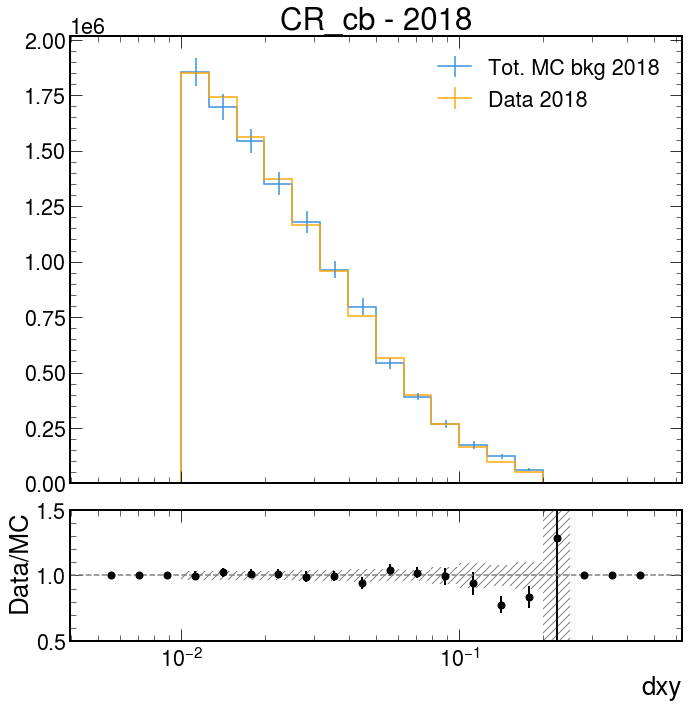

nMuon =  2.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


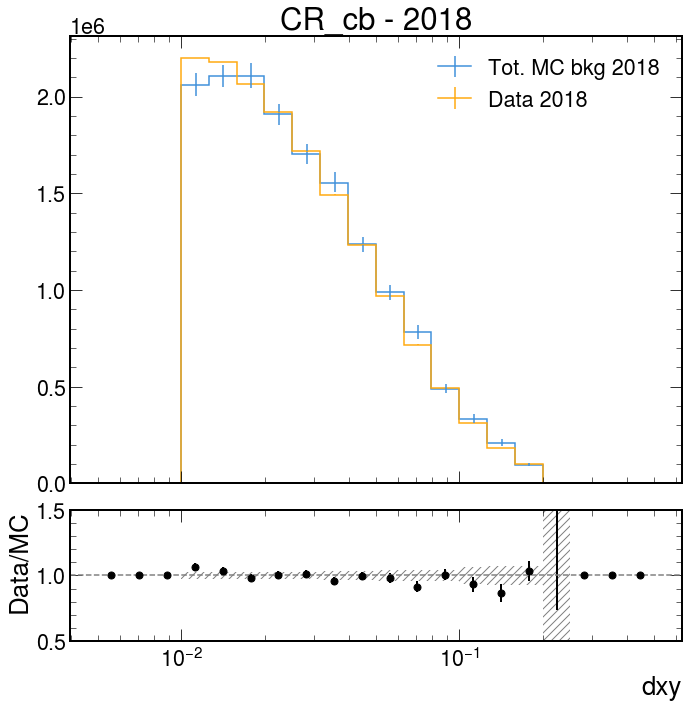

nMuon =  3.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


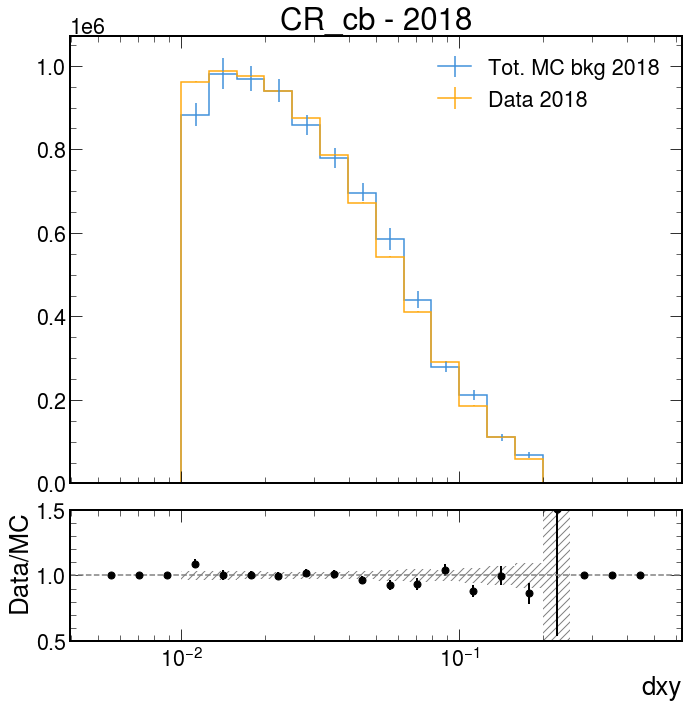

nMuon =  4.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


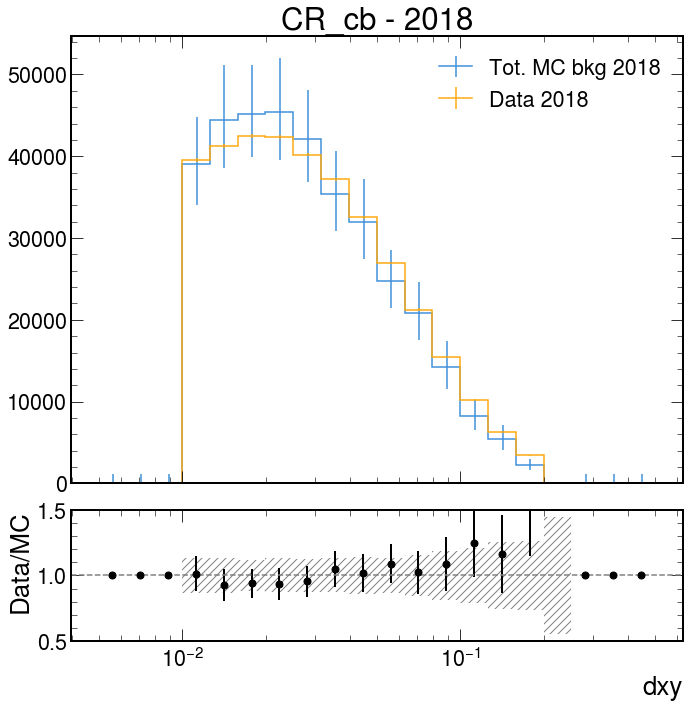

nMuon =  1.0

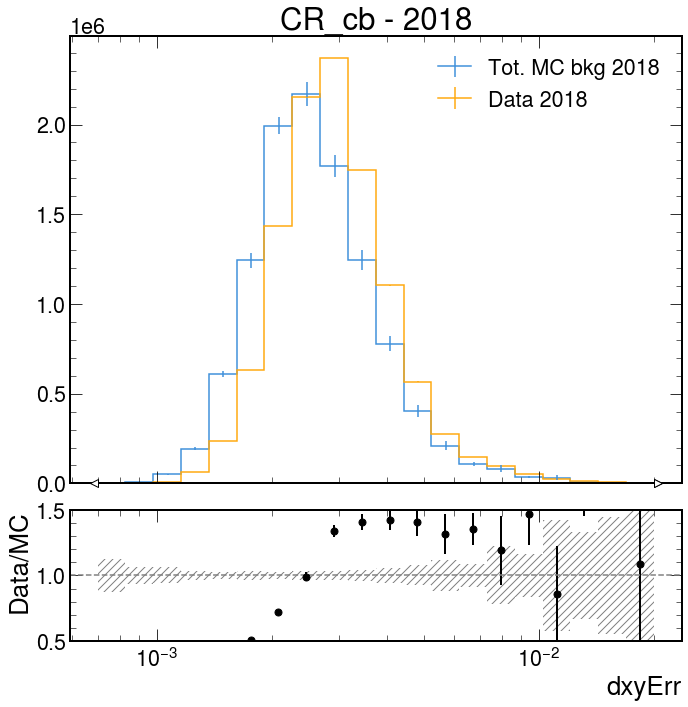

nMuon =  2.0

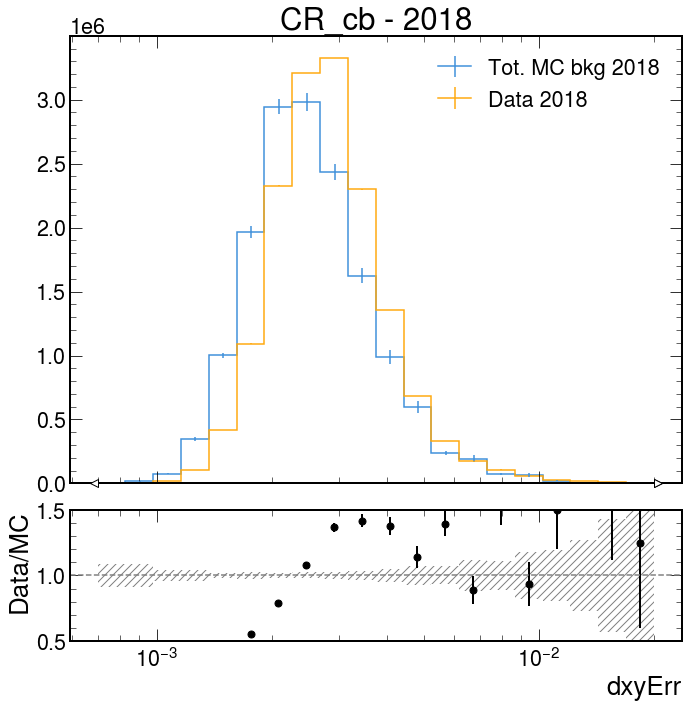

nMuon =  3.0

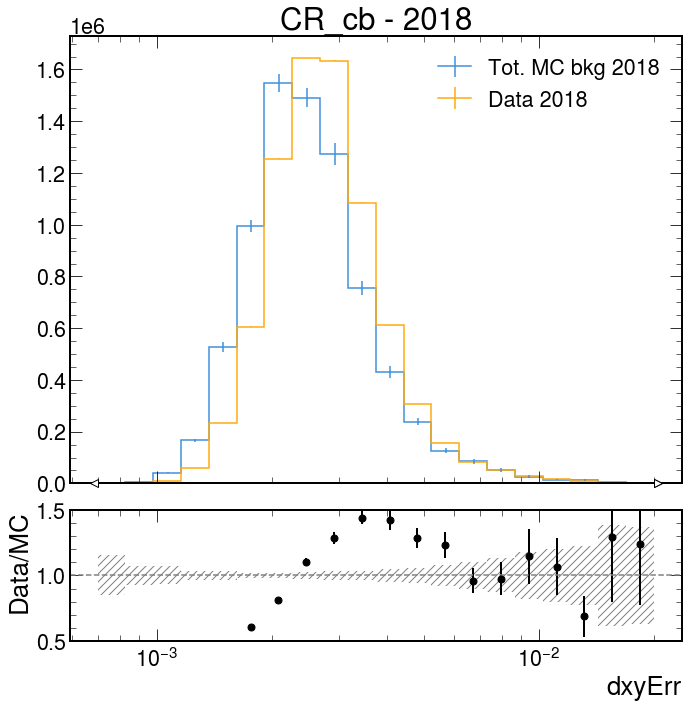

nMuon =  4.0

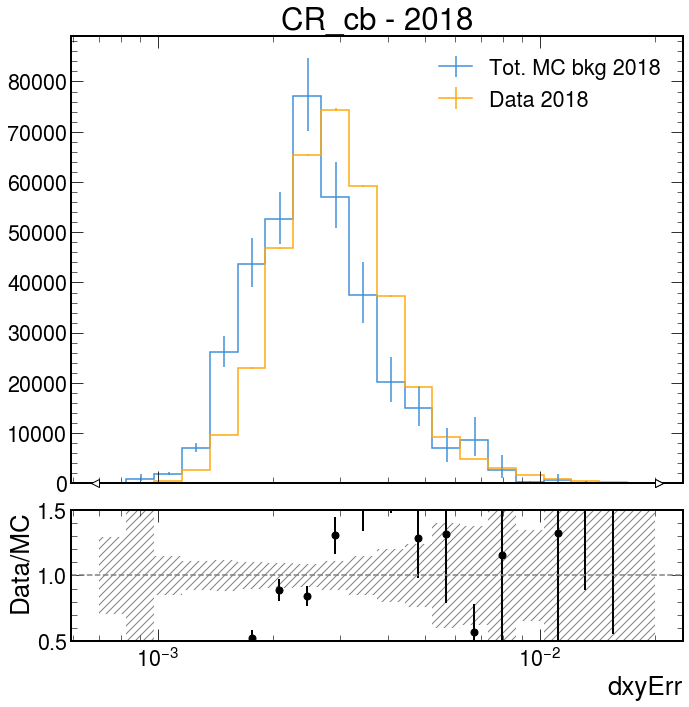

nMuon =  1.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


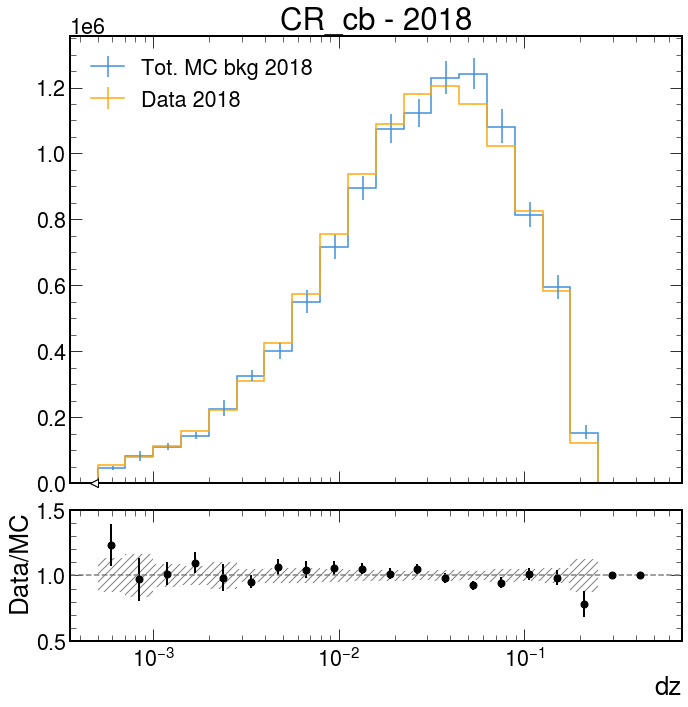

nMuon =  2.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


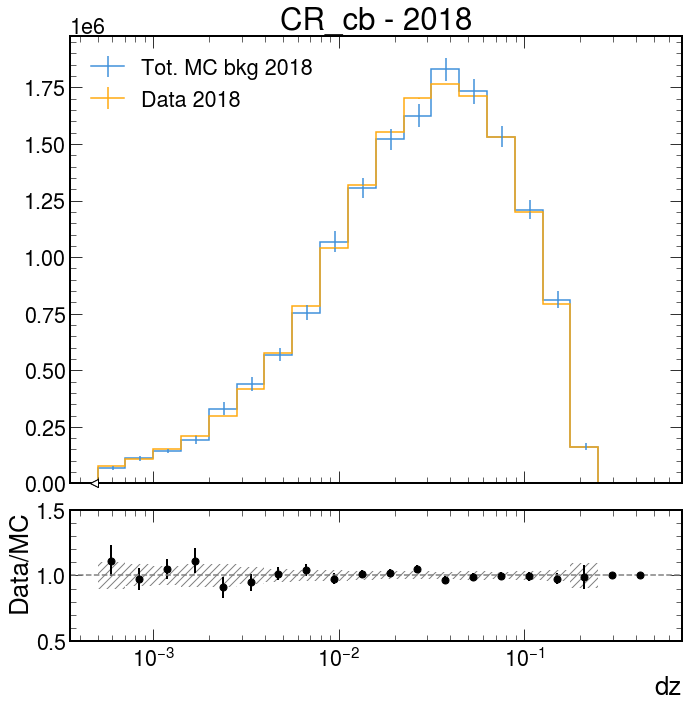

nMuon =  3.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


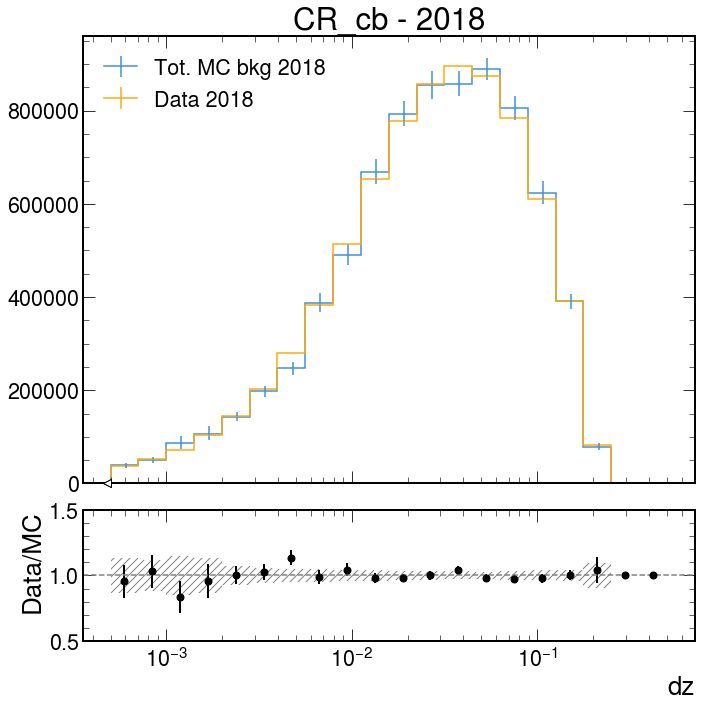

nMuon =  4.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


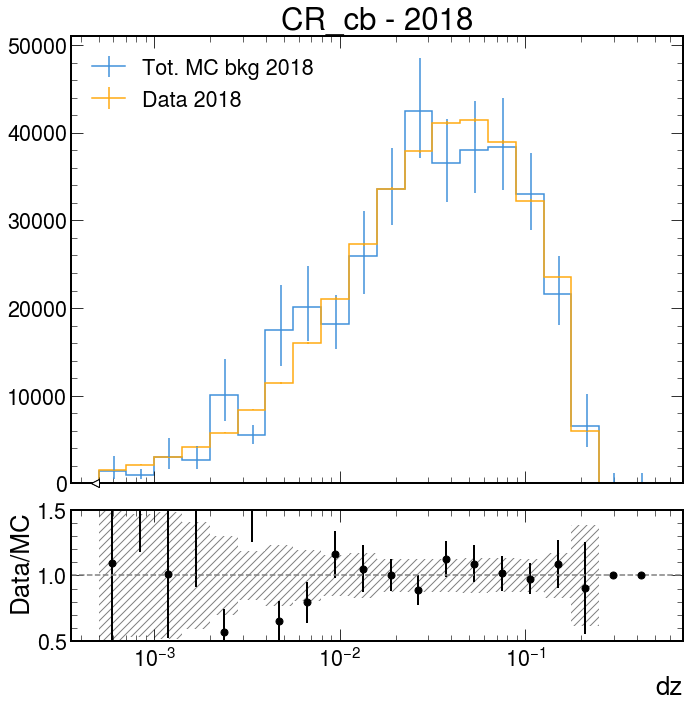

nMuon =  1.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


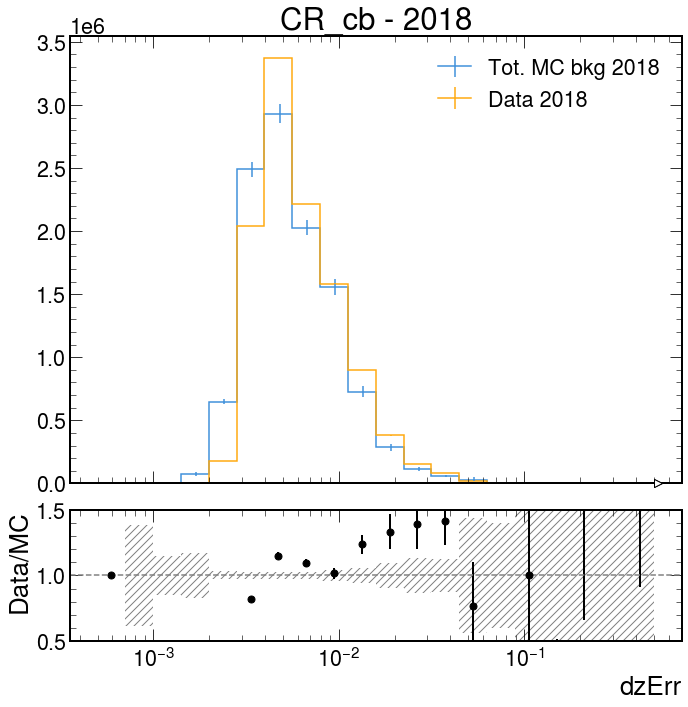

nMuon =  2.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


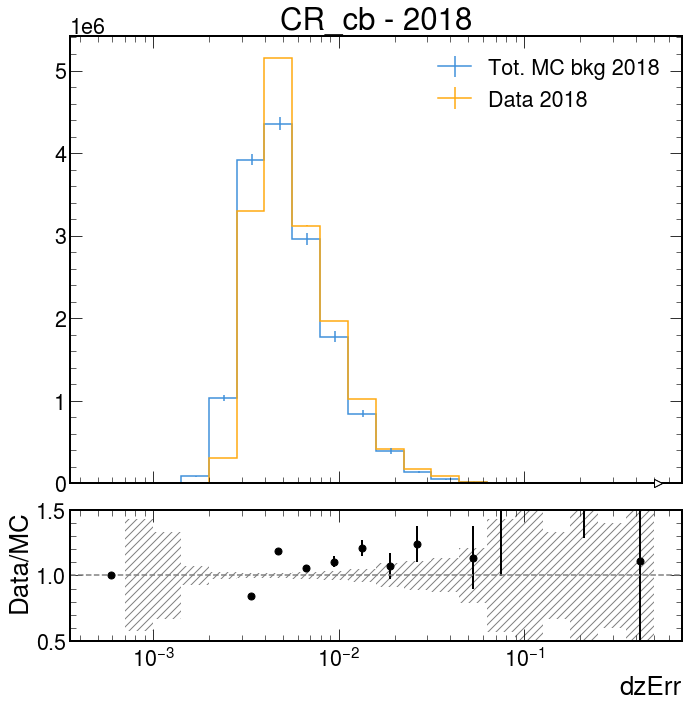

nMuon =  3.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


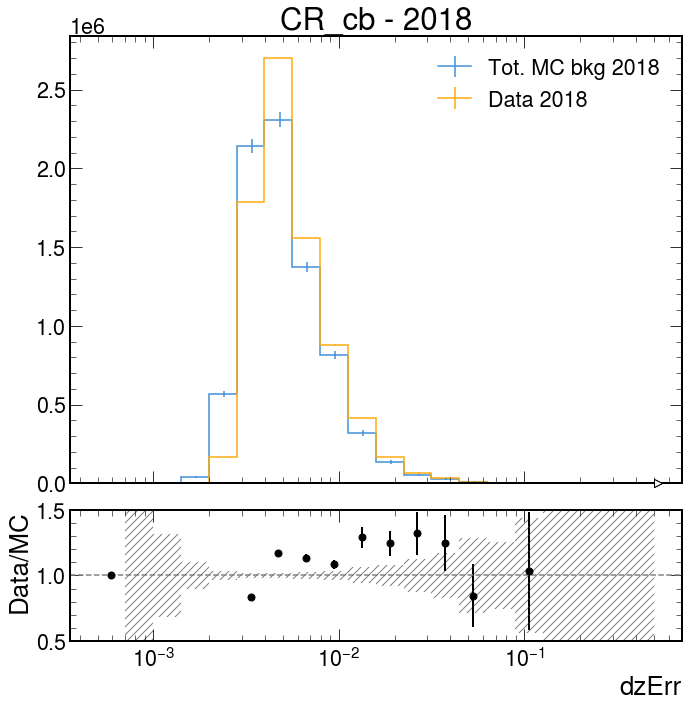

nMuon =  4.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


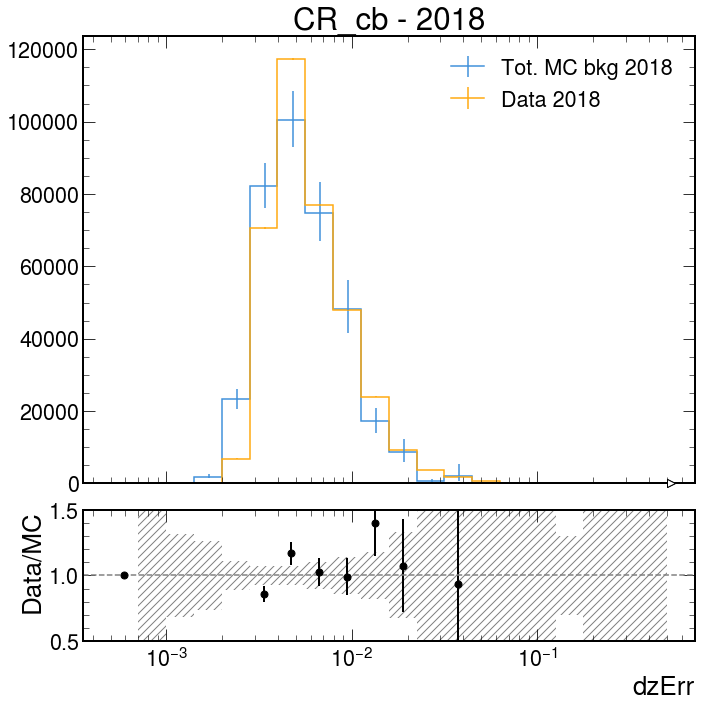

nMuon =  1.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


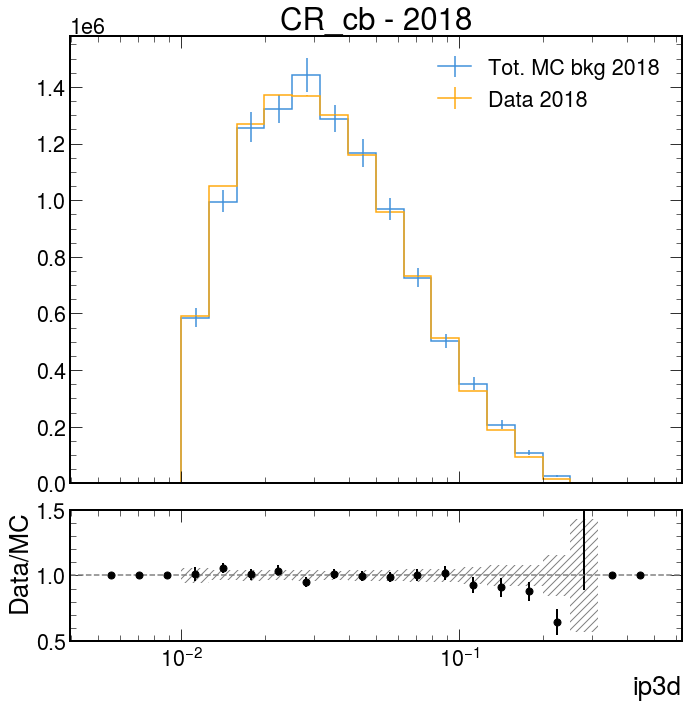

nMuon =  2.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


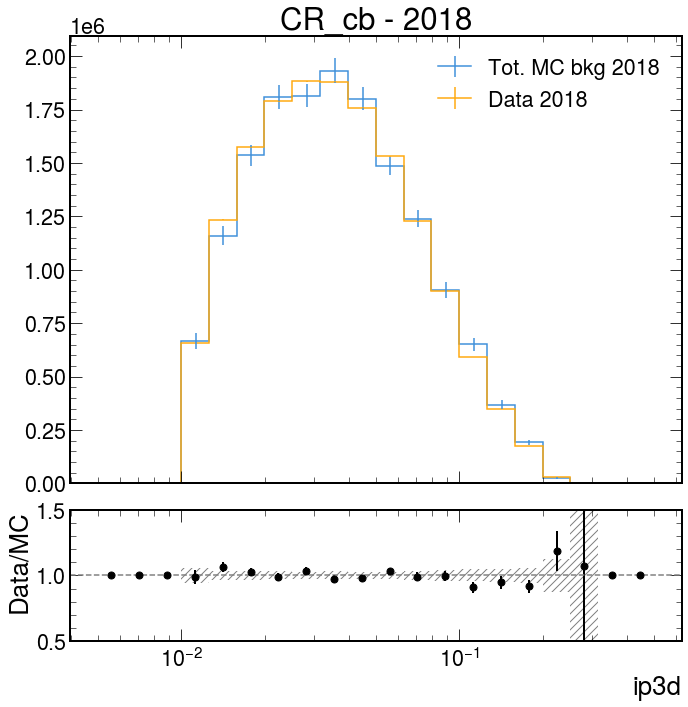

nMuon =  3.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


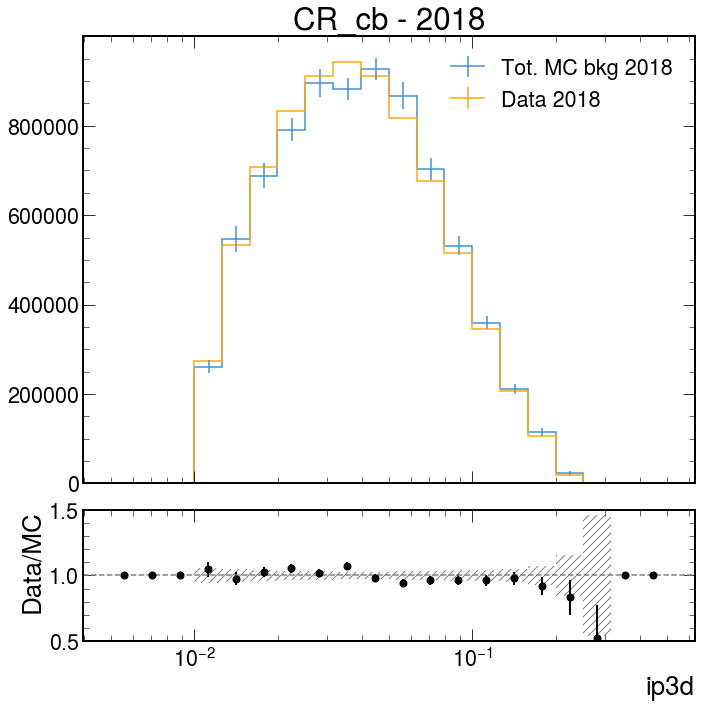

nMuon =  4.0

/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:36: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_2788255/3747817696.py:37: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


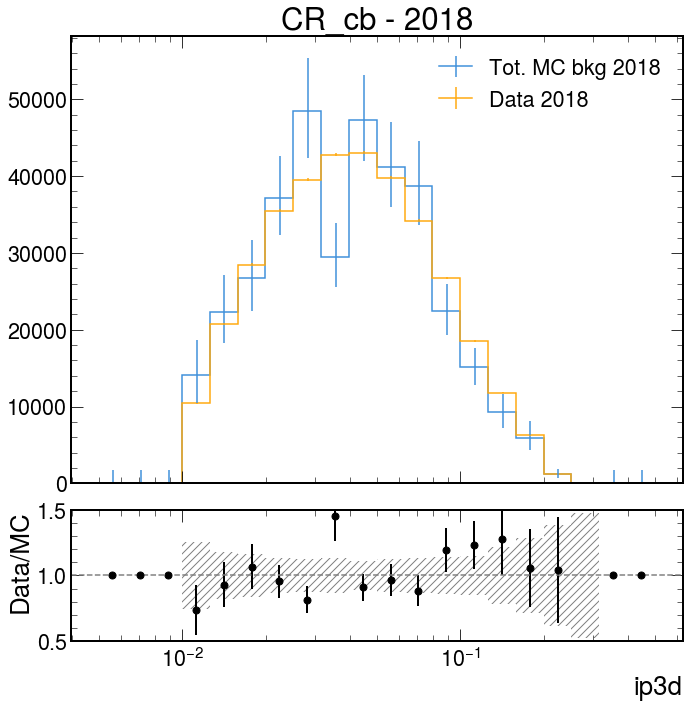

nMuon =  1.0

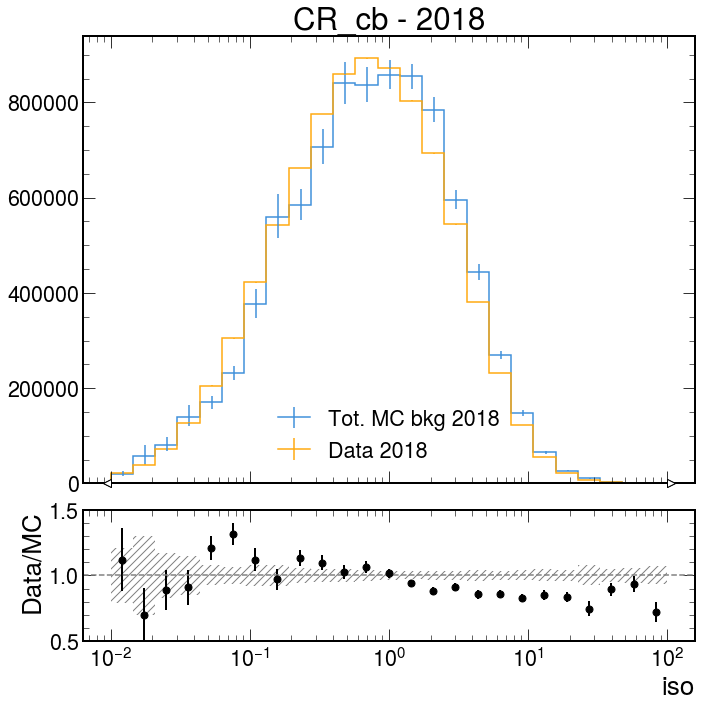

nMuon =  2.0

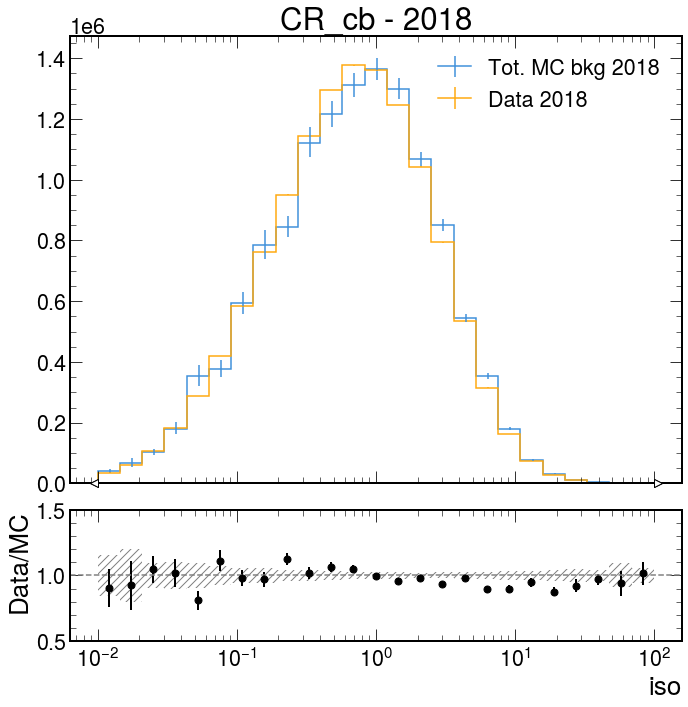

nMuon =  3.0

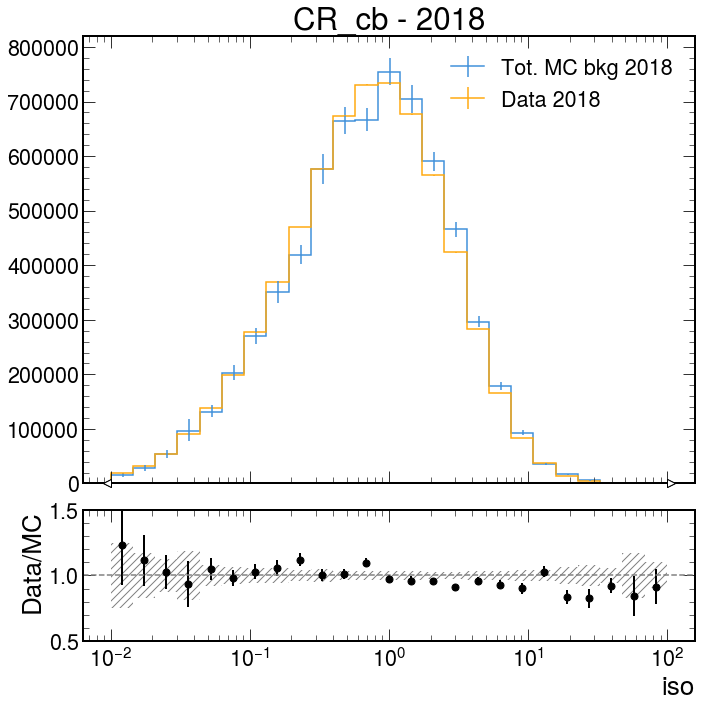

nMuon =  4.0

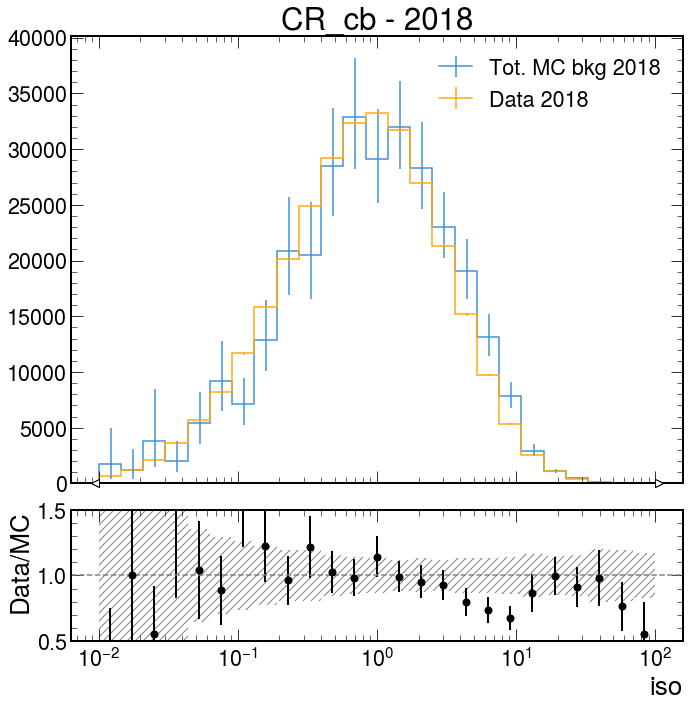

In [25]:
for era in ["2018"]:
    for region in ["prompt_prompt", "prompt_qcd", "cb"]:
        for variable in ["pt", "eta", "dxy", "dxyErr", "dz", "dzErr", "ip3d", "iso"]:
            for nMuon in plots[f"Data_{year}"][f"CR_{region}_pt"].axes[1].edges[:-1]:
                print("nMuon = ", nMuon)
                hist_data = plots[f"Data_{era}"][f"CR_{region}_{variable}"][
                    :, nMuon * 1j
                ]
                hist_bkg_total = plots[f"total_bkg_{era}"][f"CR_{region}_{variable}"][
                    :, nMuon * 1j
                ]

                # Normalize
                if hist_bkg_total.sum().value == 0:
                    continue
                normalization = hist_data.sum().value / hist_bkg_total.sum().value
                hist_bkg_total = hist_bkg_total * normalization

                fig = plt.figure(figsize=(10, 10))
                plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.95)
                ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
                ax2 = plt.subplot2grid((4, 1), (3, 0), sharex=ax1)

                hist_bkg_total.plot(label=f"Tot. MC bkg {era}", ax=ax1)
                hist_data.plot(label=f"Data {era}", ax=ax1)

                x_hatch = np.vstack(
                    (
                        hist_bkg_total.axes[0].edges[:-1],
                        hist_bkg_total.axes[0].edges[1:],
                    )
                ).reshape((-1,), order="F")

                ratio = np.divide(
                    hist_data.values(),
                    hist_bkg_total.values(),
                    out=np.ones_like(hist_data.values()),
                    where=hist_bkg_total.values() != 0,
                )
                ratio_err = np.where(
                    hist_bkg_total.values() > 0,
                    np.sqrt(
                        (hist_bkg_total.values() ** -2) * (hist_data.variances())
                        + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
                        * (hist_bkg_total.variances())
                    ),
                    0,
                )
                ax2.errorbar(
                    hist_data.axes.centers[0],
                    ratio,
                    yerr=ratio_err,
                    color="black",
                    fmt="o",
                    linestyle="none",
                    markersize=7,
                    lw=2,
                )

                # Draw a filled hatch area with the relative uncertainty of the MC in the ratio plot.
                mc_rel_unc = np.divide(
                    np.sqrt(hist_bkg_total.variances()),
                    hist_bkg_total.values(),
                    out=np.zeros_like(hist_bkg_total.values()),
                    where=hist_bkg_total.values() != 0,
                )
                y_hatch2 = np.vstack(
                    (
                        np.ones_like(hist_bkg_total.values()),
                        np.ones_like(hist_bkg_total.values()),
                    )
                ).reshape((-1,), order="F")
                y_hatch2_unc = np.vstack((mc_rel_unc, mc_rel_unc)).reshape(
                    (-1,), order="F"
                )
                ax2.fill_between(
                    x=x_hatch,
                    y1=y_hatch2 - y_hatch2_unc,
                    y2=y_hatch2 + y_hatch2_unc,
                    step="pre",
                    facecolor="none",
                    edgecolor=(0, 0, 0, 0.5),
                    linewidth=0,
                    hatch="///",
                )
                ax2.axhline(1, ls="--", color="gray")

                # ax1.set_yscale("log")
                if variable not in ["eta"]:
                    plt.xscale("log")
                plt.sca(ax2)
                plt.xlabel(variable.split("_")[-1])
                plt.ylim(0.5, 1.5)
                plt.ylabel("Data/MC")
                plt.setp(ax1.get_xticklabels(), visible=False)
                ax1.set_xlabel("", visible=False)
                ax1.set_title(f"CR_{region} - {era}")
                ax1.legend()
                plt.show()

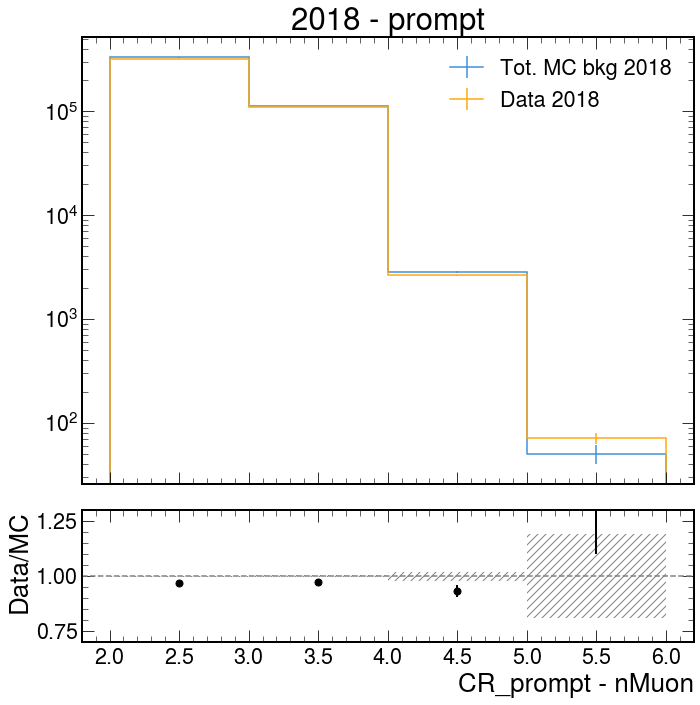

In [13]:
regions = ["prompt"]  # , "cb"]
eras = [
    "2016APV",
    "2016",
    "2017",
    "2018",
    "Run2",
    "2022",
    "2022EE",
    "2023",
    "2023BPix",
    "Run3",
]

for region in regions:
    for era in ["2018"]:
        hist_data = plots[f"Data_{era}"][f"CR_{region}_ip3d"][::sum, :]
        hist_bkg_total = plots[f"total_bkg_{era}"][f"CR_{region}_ip3d"][::sum, :]

        # Normalize
        # normalization = hist_data.sum().value / hist_bkg_total.sum().value
        # hist_bkg_total = hist_bkg_total * normalization

        fig = plt.figure(figsize=(10, 10))
        plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.95)
        ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
        ax2 = plt.subplot2grid((4, 1), (3, 0), sharex=ax1)

        hist_bkg_total.plot(label=f"Tot. MC bkg {era}", ax=ax1)
        hist_data.plot(label=f"Data {era}", ax=ax1)

        x_hatch = np.vstack(
            (hist_bkg_total.axes[0].edges[:-1], hist_bkg_total.axes[0].edges[1:])
        ).reshape((-1,), order="F")

        ratio = np.divide(
            hist_data.values(),
            hist_bkg_total.values(),
            out=np.ones_like(hist_data.values()),
            where=hist_bkg_total.values() != 0,
        )
        ratio_err = np.where(
            hist_bkg_total.values() > 0,
            np.sqrt(
                (hist_bkg_total.values() ** -2) * (hist_data.variances())
                + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
                * (hist_bkg_total.variances())
            ),
            0,
        )
        ax2.errorbar(
            hist_data.axes.centers[0],
            ratio,
            yerr=ratio_err,
            color="black",
            fmt="o",
            linestyle="none",
            markersize=7,
            lw=2,
        )

        # Draw a filled hatch area with the relative uncertainty of the MC in the ratio plot.
        mc_rel_unc = np.divide(
            np.sqrt(hist_bkg_total.variances()),
            hist_bkg_total.values(),
            out=np.zeros_like(hist_bkg_total.values()),
            where=hist_bkg_total.values() != 0,
        )
        y_hatch2 = np.vstack(
            (
                np.ones_like(hist_bkg_total.values()),
                np.ones_like(hist_bkg_total.values()),
            )
        ).reshape((-1,), order="F")
        y_hatch2_unc = np.vstack((mc_rel_unc, mc_rel_unc)).reshape((-1,), order="F")
        ax2.fill_between(
            x=x_hatch,
            y1=y_hatch2 - y_hatch2_unc,
            y2=y_hatch2 + y_hatch2_unc,
            step="pre",
            facecolor="none",
            edgecolor=(0, 0, 0, 0.5),
            linewidth=0,
            hatch="///",
        )
        ax2.axhline(1, ls="--", color="gray")

        plt.sca(ax2)
        plt.xlabel(f"CR_{region} - nMuon")
        ax1.set_yscale("log")
        plt.ylim(0.7, 1.3)
        plt.ylabel("Data/MC")
        plt.setp(ax1.get_xticklabels(), visible=False)
        ax1.set_xlabel("", visible=False)
        ax1.set_title(f"{era} - {region}")
        ax1.legend()
        plt.show()

/tmp/ipykernel_839174/156690244.py:37: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_839174/156690244.py:37: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_839174/156690244.py:38: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_839174/156690244.py:38: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


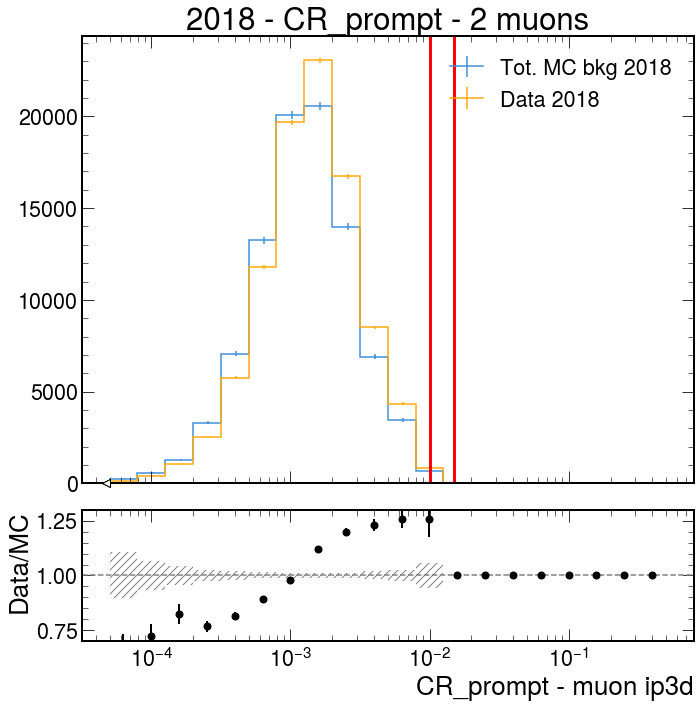

/tmp/ipykernel_839174/156690244.py:37: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_839174/156690244.py:37: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_839174/156690244.py:38: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_839174/156690244.py:38: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


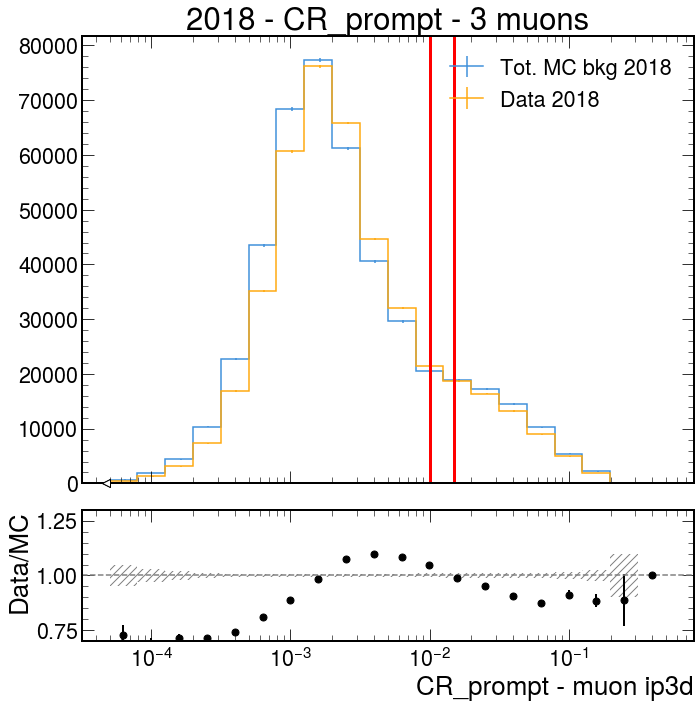

/tmp/ipykernel_839174/156690244.py:37: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_839174/156690244.py:37: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_839174/156690244.py:38: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_839174/156690244.py:38: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


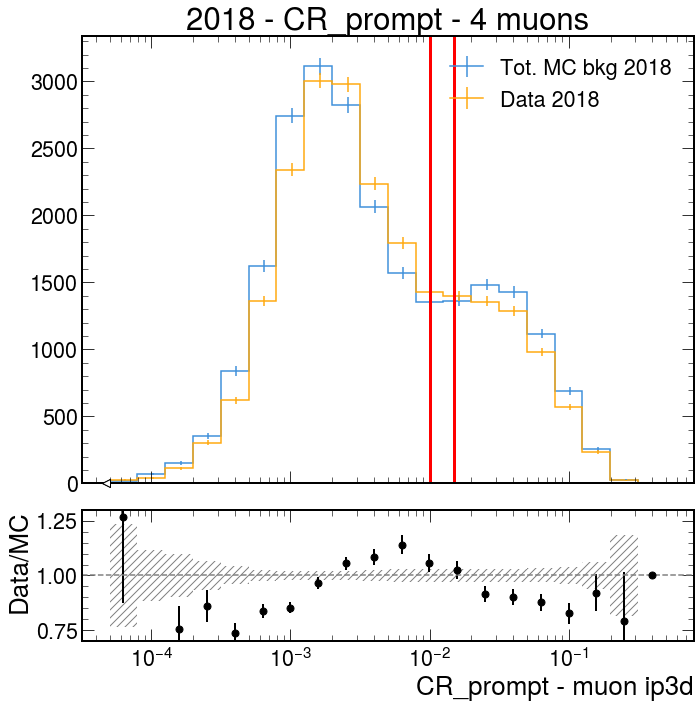

/tmp/ipykernel_839174/156690244.py:37: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_839174/156690244.py:37: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_839174/156690244.py:38: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_839174/156690244.py:38: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


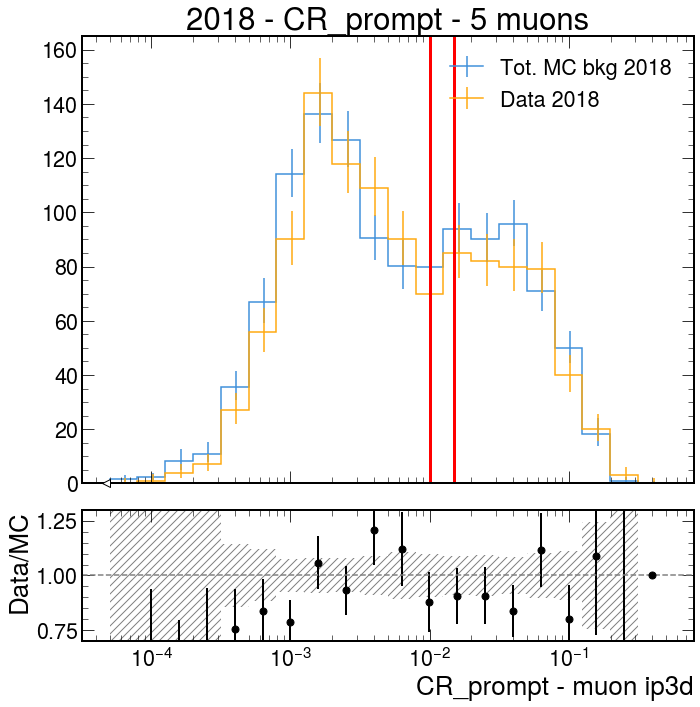

In [19]:
regions = ["prompt"]  # , "cb"]
eras = [
    "2016APV",
    "2016",
    "2017",
    "2018",
    "Run2",
    "2022",
    "2022EE",
    "2023",
    "2023BPix",
    "Run3",
]
variables = ["pt", "eta", "dxy", "dz", "ip3d", "iso"]

for region in regions:
    for era in ["2018"]:
        for nMuon in range(2, 6):
            variable = "ip3d"
            hist_data = plots[f"Data_{era}"][f"CR_{region}_{variable}"][:, nMuon * 1j]
            hist_bkg_total = plots[f"total_bkg_{era}"][f"CR_{region}_{variable}"][
                :, nMuon * 1j
            ]

            # Normalize
            # normalization = hist_data.sum().value / hist_bkg_total.sum().value
            # hist_bkg_total = hist_bkg_total * normalization

            fig = plt.figure(figsize=(10, 10))
            plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.95)
            ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
            ax2 = plt.subplot2grid((4, 1), (3, 0), sharex=ax1)

            hist_bkg_total.plot(label=f"Tot. MC bkg {era}", ax=ax1)
            hist_data.plot(label=f"Data {era}", ax=ax1)

            x_hatch = np.vstack(
                (hist_bkg_total.axes[0].edges[:-1], hist_bkg_total.axes[0].edges[1:])
            ).reshape((-1,), order="F")

            ratio = np.divide(
                hist_data.values(),
                hist_bkg_total.values(),
                out=np.ones_like(hist_data.values()),
                where=hist_bkg_total.values() != 0,
            )
            ratio_err = np.where(
                hist_bkg_total.values() > 0,
                np.sqrt(
                    (hist_bkg_total.values() ** -2) * (hist_data.variances())
                    + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
                    * (hist_bkg_total.variances())
                ),
                0,
            )
            ax2.errorbar(
                hist_data.axes.centers[0],
                ratio,
                yerr=ratio_err,
                color="black",
                fmt="o",
                linestyle="none",
                markersize=7,
                lw=2,
            )

            # Draw a filled hatch area with the relative uncertainty of the MC in the ratio plot.
            mc_rel_unc = np.divide(
                np.sqrt(hist_bkg_total.variances()),
                hist_bkg_total.values(),
                out=np.zeros_like(hist_bkg_total.values()),
                where=hist_bkg_total.values() != 0,
            )
            y_hatch2 = np.vstack(
                (
                    np.ones_like(hist_bkg_total.values()),
                    np.ones_like(hist_bkg_total.values()),
                )
            ).reshape((-1,), order="F")
            y_hatch2_unc = np.vstack((mc_rel_unc, mc_rel_unc)).reshape((-1,), order="F")
            ax2.fill_between(
                x=x_hatch,
                y1=y_hatch2 - y_hatch2_unc,
                y2=y_hatch2 + y_hatch2_unc,
                step="pre",
                facecolor="none",
                edgecolor=(0, 0, 0, 0.5),
                linewidth=0,
                hatch="///",
            )
            ax2.axhline(1, ls="--", color="gray")

            if variable == "pt":
                ax1.axvline(x=25, color="red", ymin=0, ymax=1e6, lw=3)
            if variable == "iso":
                ax1.axvline(x=0.1, color="red", ymin=0, ymax=1e6, lw=3)
            if variable == "dxy":
                ax1.axvline(x=0.008, color="red", ymin=0, ymax=1e6, lw=3)
            if variable == "dz":
                ax1.axvline(x=0.01, color="red", ymin=0, ymax=1e6, lw=3)
            if variable == "ip3d":
                ax1.axvline(x=0.01, color="red", ymin=0, ymax=1e6, lw=3)
                ax1.axvline(x=0.015, color="red", ymin=0, ymax=1e6, lw=3)

            if variable in ["pt", "dxy", "dz", "ip3d", "iso"]:
                plt.xscale("log")
            plt.sca(ax2)
            plt.xlabel(f"CR_{region} - muon {variable}")
            plt.ylim(0.7, 1.3)
            plt.ylabel("Data/MC")
            plt.setp(ax1.get_xticklabels(), visible=False)
            ax1.set_xlabel("", visible=False)
            ax1.set_title(f"{era} - CR_{region} - {nMuon} muons")
            ax1.legend()
            plt.show()

In [38]:
regions = ["prompt", "cb"]
eras = [
    "2016APV",
    "2016",
    "2017",
    "2018",
    "Run2",
    "2022",
    "2022EE",
    "2023",
    "2023BPix",
    "Run3",
]
variables = ["pt", "eta", "dxy", "dz", "ip3d", "iso"]

with PdfPages("data_vs_mc_nMuon2.pdf") as pdf:
    with Progress() as progress:
        task = progress.add_task(
            "Plotting", total=len(regions) * len(eras) * len(variables)
        )
        for region in regions:
            for era in eras:
                for variable in variables:
                    hist_data = plots[f"Data_{era}"][f"CR_{region}_{variable}"][:, 2j]
                    hist_bkg_total = plots[f"total_bkg_{era}"][
                        f"CR_{region}_{variable}"
                    ][:, 2j]

                    normalization = hist_data.sum().value / hist_bkg_total.sum().value
                    hist_bkg_total = hist_bkg_total * normalization

                    fig = plt.figure(figsize=(10, 10))
                    plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.95)
                    ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
                    ax2 = plt.subplot2grid((4, 1), (3, 0), sharex=ax1)

                    hist_bkg_total.plot(label=f"Tot. MC bkg {era}", ax=ax1)
                    hist_data.plot(label=f"Data {era}", ax=ax1)

                    x_hatch = np.vstack(
                        (
                            hist_bkg_total.axes[0].edges[:-1],
                            hist_bkg_total.axes[0].edges[1:],
                        )
                    ).reshape((-1,), order="F")

                    ratio = np.divide(
                        hist_data.values(),
                        hist_bkg_total.values(),
                        out=np.ones_like(hist_data.values()),
                        where=hist_bkg_total.values() != 0,
                    )
                    ratio_err = np.where(
                        hist_bkg_total.values() > 0,
                        np.sqrt(
                            (hist_bkg_total.values() ** -2) * (hist_data.variances())
                            + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
                            * (hist_bkg_total.variances())
                        ),
                        0,
                    )
                    ax2.errorbar(
                        hist_data.axes.centers[0],
                        ratio,
                        yerr=ratio_err,
                        color="black",
                        fmt="o",
                        linestyle="none",
                        markersize=7,
                        lw=2,
                    )

                    # Draw a filled hatch area with the relative uncertainty of the MC in the ratio plot.
                    mc_rel_unc = np.divide(
                        np.sqrt(hist_bkg_total.variances()),
                        hist_bkg_total.values(),
                        out=np.zeros_like(hist_bkg_total.values()),
                        where=hist_bkg_total.values() != 0,
                    )
                    y_hatch2 = np.vstack(
                        (
                            np.ones_like(hist_bkg_total.values()),
                            np.ones_like(hist_bkg_total.values()),
                        )
                    ).reshape((-1,), order="F")
                    y_hatch2_unc = np.vstack((mc_rel_unc, mc_rel_unc)).reshape(
                        (-1,), order="F"
                    )
                    ax2.fill_between(
                        x=x_hatch,
                        y1=y_hatch2 - y_hatch2_unc,
                        y2=y_hatch2 + y_hatch2_unc,
                        step="pre",
                        facecolor="none",
                        edgecolor=(0, 0, 0, 0.5),
                        linewidth=0,
                        hatch="///",
                    )
                    ax2.axhline(1, ls="--", color="gray")

                    if variable in ["pt", "ip3d", "iso"]:
                        plt.xscale("log")
                    plt.sca(ax2)
                    plt.xlabel(f"CR_{region} - muon {variable}")
                    plt.ylim(0.75, 1.25)
                    plt.ylabel("Data/MC")
                    plt.setp(ax1.get_xticklabels(), visible=False)
                    ax1.set_xlabel("", visible=False)
                    ax1.set_title(f"{era} - {region}")
                    ax1.legend()
                    pdf.savefig(fig)  # Saves the current figure into the PDF
                    plt.close(fig)  # Close the figure after saving to free memory
                    progress.update(task, advance=1)

Plotting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸  99% 0:00:01
Plotting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸  99% 0:00:01